# Individuality in the *non-emerging* measures

The syllable pipeline finds individuality it was never told to look for: LDA is handed
56 class labels and 360 syllable-composition features, and the axes that fall out are a
description of a mouse nobody wrote down. This notebook asks the same questions of the
measures that **were** written down — accuracy, reaction time, block bias, engagement —
the ones an IBL analysis would report anyway. They are "non-emerging" in exactly that
sense: hand-defined task summaries, one number per session, each with a name and a unit
before any model touched it.

Two questions, in order.

**1. Do the syllables track these measures?** Same figure as `4_mice/lda_shrinkage.ipynb`'s
structural-coefficient panel — per-timestep correlation between each syllable and a
score, with a permutation band — but the score is a behavioural summary instead of an LD
axis. If the movement features that identify a mouse are the same ones that carry its
reaction time, that is worth knowing; if they are not, the individuality axis is not a
restatement of the task metrics.

**2. Is each measure individual at all?** A mouse's accuracy varies from session to
session. The individuality claim is that it varies *less* than accuracy varies between
mice. That ratio is a repeatability (ICC), and it is the number this notebook exists to
produce — one per measure, against a permutation null and a bootstrap interval, with the
lab split out, because lab is nested inside mouse and will otherwise be read as
individuality.

---

### Three things to hold on to while reading

**`log_training` is not a session measure.** Learning speed is one number per mouse, so
its within-mouse variance is zero and its repeatability is 1.0 by construction, not by
biology. It is kept in the correlation analysis (where a per-mouse trait is a perfectly
good regressor) and excluded from the repeatability table, where it would be a
tautology. The code enforces this rather than trusting the reader.

**The LD axes are circular here.** LD1–LD3 are included as reference rows because the
comparison is the point, but they were *fit* to maximise between-mouse separation on
these same sessions. Their repeatability is an upper bound on what the fit can achieve,
not an out-of-sample property, and it is not comparable to a measure that was never
optimised. The honest comparison to the syllables is the held-out identification score
at the bottom of the notebook.

**Four of the measures come out of a model that was fit per mouse.** `p_engaged` and
the three engagement-transition measures are read off the GLM-HMM state path, and that
model is fit separately for each animal. Between-mouse differences in them are therefore
part behaviour and part fit, their repeatability is biased upward, and every figure marks
them so the comparison with the raw task measures is not read as like for like.

**The choice labels in this repo are mirrored.** `1_segmentation/functions.py` writes
`choice = 'right'` for ALF `+1`, which is the counter-clockwise turn — the report of a
stimulus on the **left**. Anything sign-blind (accuracy, |bias|) is unaffected; the two
signed measures here (`bias`, `signed_choice_bias`) are not. This notebook therefore
builds its trials through `laterality/laterality_features.trial_features()`, which
recovers the stimulus side from choice × feedback and orients it on `block`
(`probabilityLeft`, straight from ALF and not mirrored), and prints the check. Note that
`4_mice/LDA_behavior.ipynb` does **not** do this, so its `bias` and `signed_choice_bias`
have the opposite sign to the ones here.

## Knobs

Everything that changes an answer is here. The cohort screens are copied from
`4_mice/lda_shrinkage.ipynb` deliberately — the point is to describe the *same* mice and
sessions the LDA describes, so the two notebooks' numbers can sit in one sentence.

In [41]:
# ---- COHORT (matched to 4_mice/lda_shrinkage.ipynb) --------------------------------
QC_STRICTNESS = 'filtered_out'
# Which sessions the curated QC sheet removes (session_filters.exclusions_by_timepoint):
#   'filtered_out'            -> 'Used in paper' == 'filtered out'   (12 proficient)
#   'filtered_out_and_revise' -> those PLUS 'need to revise'

MAX_SESSION_MISSING = 0.1
# Drop sessions with more than this fraction of NaN syllable bins. None keeps every one.

MIN_SESSIONS_PER_MOUSE = 3
# Applied AFTER the syllable/trial join, not before: a mouse that has 4 syllable sessions
# but only 2 with trial metadata contributes 2 here, and 2 sessions cannot support a
# within-mouse variance. Both files' cohorts are printed so the cost is visible.

MIN_TRIALS = 100
# A session below this cannot support a psychometric curve, so its bias estimates are
# noise. laterality_features' own floor; repeated here so it is a knob and not a default.

# ---- WHAT COUNTS AS A MEASURE -----------------------------------------------------
# key -> (label for figures, whether it is a per-SESSION measure or a per-MOUSE trait)
# Only 'session' measures get a repeatability; a trait has no within-mouse variance.
METRIC_SPEC = {
    'correct':            ('Accuracy (easy trials)',    'session'),
    'log_reaction':       ('log Reaction time',         'session'),
    'log_elongation':     ('log Trial elongation',      'session'),
    'bias':               ('Block bias shift (0%)',     'session'),
    'signed_choice_bias': ('Choice bias (signed)',      'session'),
    'choice_bias':        ('Choice bias (magnitude)',   'session'),
    'p_engaged':          ('P(engaged)',                'session'),
    'p_switch':           ('Engagement switch rate',    'session'),
    'p_eng_to_dis':       ('P(engaged -> disengaged)',  'session'),
    'p_dis_to_eng':       ('P(disengaged -> engaged)',  'session'),
    'trial_count':        ('Trials completed',          'session'),
    'log_training':       ('Learning speed (log days)', 'mouse'),
}

MODEL_DERIVED = {'p_engaged', 'p_switch', 'p_eng_to_dis', 'p_dis_to_eng'}
# THESE FOUR ARE NOT RAW OBSERVABLES. They are read off the GLM-HMM state path, and
# fit_and_save_all_k.py fits that model SEPARATELY FOR EACH MOUSE, pooling all of that
# mouse's sessions under one shared transition matrix and one set of GLM weights. So a
# between-mouse difference in these measures is partly a difference between the fits:
# the per-session numbers vary because the posterior varies, but they are shrunk toward
# parameters that were estimated per animal in the first place. Their repeatability is
# therefore biased UPWARD for the same reason the LD axes' is, if less severely, and
# every figure marks them. A clean version needs one model fit across all mice.

MIN_DISENGAGED = 20
# P(disengaged -> engaged) is estimated from the disengaged trials only, and a session
# with 4 of them gives a rate of 0, 0.25 or 0.5 and nothing in between. Below this many
# the measure is NaN rather than a number, which costs sessions -- the count is printed.
# The other two transition measures have the whole session as their denominator.

# ---- THE LD AXES, AS A REFERENCE ROW ----------------------------------------------
LDA_FILE = 'mouse_LDA_5_bins_raw_shrink0.5_360_22-09-2026'
# In clustering/data_files/. None skips it. READ THE HEADER: these axes were fit to
# separate these mice on these sessions, so their repeatability is an upper bound of the
# fit, not an out-of-sample property. They are here for the correlation panels and as a
# ceiling on the repeatability plot, labelled as circular in both.
N_LD_REFERENCE = 3

# ---- PART 1: CORRELATION PROFILES -------------------------------------------------
PROFILE_UNIT = 'session'
# Which correlation the profile figure draws, and what its permutation null shuffles:
#   'mouse'    one point per mouse (mouse-mean syllable vs mouse-mean measure), null
#              permutes the measure across MICE. n = n_mice. The between-animal
#              question, and the only unit whose p-value is not pseudoreplicated.
#   'session'  one point per session, null permutes across sessions. This is what
#              lda_shrinkage does. Sessions of one mouse are not independent, so the
#              band is TOO NARROW -- it counts a 13-session mouse thirteen times.
#   'within'   both variables centred on their own mouse's mean, null permutes the
#              measure WITHIN mouse. The session-to-session question: when this mouse
#              is slower than usual, which syllables move? Undefined for a 'mouse'
#              trait, which has no within-mouse variation (returns NaN, and says so).
# All three are computed for the summary table regardless; this picks the figure.

N_PERMS_PROFILE = 1000
ALPHA_IN_BAND = 0.2       # opacity of the trace inside the null band

# ---- PART 2: REPEATABILITY --------------------------------------------------------
N_PERMS_ICC = 1000
N_BOOT_ICC = 1000
PERM_WITHIN_LAB = True
# True  shuffles session -> mouse assignments WITHIN each lab, so the null keeps every
#       lab difference and the p-value asks for mouse structure BEYOND lab. With lab
#       nested in mouse this is the only version that means anything on its own.
# False shuffles across the whole cohort; the null then contains no structure at all and
#       every measure with any lab effect comes out significant.

# ---- PART 3: IDENTIFICATION -------------------------------------------------------
N_PER_MOUSE = 3           # cap per mouse in a training set, as in lda_shrinkage
ID_SHRINKAGE = 0.1
ID_REPEATS = 5
# log_training is EXCLUDED from the identification features by construction (see the
# cell): it is constant within a mouse, so it hands the classifier the label.

SAVE_TABLES = True        # write the summary CSVs next to this notebook
RANDOM_SEED = 0

### Figure style

`paper_style` holds every cross-figure decision — colours, panel sizes, where figures are
written. Run this before the imports cell.

In [42]:
# ---- FIGURE STYLE -----------------------------------------------------------------
import sys
import pathlib


def _find_paper_style():
    here = pathlib.Path.cwd().resolve()
    for cand in [here, *here.parents]:
        if (cand / 'paper_style.py').exists():
            return cand
        if (cand / 'paper-individuality' / 'paper_style.py').exists():
            return cand / 'paper-individuality'
    raise FileNotFoundError(f'paper_style.py not found above {here}')


_root = _find_paper_style()
for _p in (_root,
           _root / 'learning_individuality',   # session_filters lives there
           _root / '4_mice',                   # functions.py
           _root / '4_mice' / 'laterality',    # laterality_features.py
           _root / 'lab'):                     # variance_partition.py
    if str(_p) not in sys.path:
        sys.path.insert(0, str(_p))

import importlib
import paper_style
importlib.reload(paper_style)      # kernels cache modules; without this, edits stay invisible
ps = paper_style
ps.use('poster')                   # 'poster' = big type; 'paper' = journal sizes

paper_style: poster mode, spines=lb, font 16 pt, panels 7.0x5.0 in, save 300 dpi


'poster'

## Imports and paths

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy import stats

import functions
importlib.reload(functions)
import laterality_features as lf
importlib.reload(lf)
import variance_partition as vp
importlib.reload(vp)

DATA = _root / 'data'
SYLLABLE_FILE = DATA / '8_k_10_bin_syllables_19-08-2026'
TRIAL_FILE = DATA / 'session_trial_meta_10-07-2026'
TRAINING_FILE = _root.parent / 'learning_prediction' / 'training_time_05-05-2026'
HERE = pathlib.Path.cwd()

N_PAW_STATES = ps.N_PAW_STATES                 # 8
EPOCHS = ps.EPOCH_NAMES                        # the four trial epochs, in order
SYLLABLES = ps.SYLLABLE_NAMES                  # Paw 0..7, Whisk, Lick
RNG = np.random.default_rng(RANDOM_SEED)

for _f in (SYLLABLE_FILE, TRIAL_FILE, TRAINING_FILE):
    assert _f.exists(), f'missing input: {_f}'
print('inputs OK'
      f'\n  syllables {SYLLABLE_FILE.name}'
      f'\n  trials    {TRIAL_FILE.name}'
      f'\n  training  {TRAINING_FILE.name}')

inputs OK
  syllables 8_k_10_bin_syllables_19-08-2026
  trials    session_trial_meta_10-07-2026
  training  training_time_05-05-2026


## The measures

One row per session. Every definition is spelled out here rather than inherited, because
three of them differ from `4_mice/LDA_behavior.ipynb` and the differences change signs
and drop sessions:

| measure | here | LDA_behavior |
|---|---|---|
| `bias` | `P(right \| p(left)=0.2) − P(right \| p(left)=0.8)` at 0% contrast, **screen-oriented**, so positive = the mouse uses the block | `P(right\|0.8) − P(right\|0.2)` on the mirrored labels: same magnitude, opposite sign |
| `signed_choice_bias` | screen-oriented: positive = chose RIGHT more than the stimuli called for | mirrored: positive = chose LEFT more |
| `log_reaction`, `log_elongation` | `log1p` | `log`, which is NaN for the sessions whose median reaction time is slightly negative (first movement before the go cue) and silently drops them |

`log1p(x) = log(1 + x)` is finite and monotone for every `x > −1`, which covers a
negative median reaction time; `functions.build_design_matrix` already made this switch
for the same reason.

The rest: `correct` is accuracy on contrast > 0.5 (the easy trials, where a mistake is
not a perceptual failure); `choice_bias` is `|signed_choice_bias|`, so it answers
"biased at all?" while the signed one answers "which way?" — one question asked twice,
not two findings; `trial_count` is trials completed, which is a measure of the *session*
far more than of the mouse and is here partly as a control for exactly that.

### The engagement measures

Four of them, all read off the GLM-HMM state path (`p_state1`, and `dominant_state`,
which is exactly `p_state1 ≥ 0.5`):

| | |
|---|---|
| `p_engaged` | session-mean posterior for the engaged state — *how much* of the session was engaged |
| `p_switch` | fraction of consecutive trial pairs where the state changes — how *labile* the session was |
| `p_eng_to_dis` | P(disengaged at t+1 \| engaged at t) — the hazard of dropping out. 1/this is the mean engaged run length |
| `p_dis_to_eng` | P(engaged at t+1 \| disengaged at t) — how fast the mouse recovers |

A level and two hazards are not the same measurement. Two mice can spend the same
fraction of a session disengaged while one takes a single long lapse and the other
flickers in and out every few trials, and only the transition rates tell them apart.

The rates are computed on the **raw** trial table, not on the sign-corrected one, because
`trial_features` drops no-go trials and a transition is a property of consecutive trials:
removing one from the middle of a run splices together two trials that were never
adjacent and invents a transition. `trial_id` is asserted contiguous within a session, and
no pair is ever formed across a session boundary.

`p_dis_to_eng` has the disengaged trials as its denominator, and in a session with a
handful of them the only available answers are 0, ¼, ½… — coarse values that would read as
real between-session variation. Sessions under `MIN_DISENGAGED` get NaN instead, and the
count is printed. **All four inherit the caveat in the header: the model behind them was
fit one mouse at a time.**

In [44]:
def build_session_metrics(trial_file, training_file, min_trials=MIN_TRIALS):
    """-> one row per session: mouse_name + every key in METRIC_SPEC.

    Trials come from laterality_features.trial_features(), which is the only loader in
    the repo that fixes the mirrored choice labels; it prints its orientation check, and
    raises rather than guessing if `block` does not separate the stimulus side. On the
    way out of it the convention is: signed_contrast > 0 = stimulus on the RIGHT,
    choice_right == 1 = the mouse reported RIGHT, block = p(left).
    """
    tr = lf.trial_features(path=trial_file, min_trials=min_trials, verbose=True)

    g = tr.groupby('session')
    out = pd.DataFrame({'mouse_name': g['mouse_name'].first(), 'trial_count': g.size()})
    out['log_reaction'] = np.log1p(g['reaction'].median())
    out['log_elongation'] = np.log1p(g['elongation'].median())

    # accuracy where the stimulus is unambiguous
    out['correct'] = tr.loc[tr['contrast'] > 0.5].groupby('session')['correct'].mean()

    # BLOCK BIAS SHIFT at 0% contrast. block IS p(left), so the 0.2 block is the one
    # where right stimuli are common and P(right) is highest -- 0.2 minus 0.8, in that
    # order, is the direction that makes "uses the block" positive.
    zero = tr.loc[tr['contrast'] == 0]
    by_block = zero.groupby(['session', 'block'])['choice_right'].mean().unstack('block')
    missing = by_block[[0.2, 0.8]].isna().any(axis=1).sum()
    if missing:
        print(f'  {missing} sessions have no 0% trials in one of the biased blocks; '
              'their `bias` is NaN rather than imputed')
    out['bias'] = by_block[0.2] - by_block[0.8]

    # CHOICE BIAS on visible stimuli: how far P(right) sits from what the stimulus side
    # distribution alone would produce. Subtracting the expected rate matters because the
    # block structure makes the two sides unequal within a session.
    vis = tr.loc[tr['contrast'] > 0].copy()
    vis['expected_right'] = (vis['signed_contrast'] > 0).astype(float)
    cb = vis.groupby('session').agg(observed=('choice_right', 'mean'),
                                    expected=('expected_right', 'mean'))
    out['signed_choice_bias'] = cb['observed'] - cb['expected']
    out['choice_bias'] = out['signed_choice_bias'].abs()

    # ENGAGEMENT AND ITS TRANSITIONS. p_state1 is the GLM-HMM posterior for the engaged
    # state and lives only in the raw meta file -- trial_features does not carry it
    # through. The transition rates are computed from the RAW file too, not from `tr`,
    # because tr drops no-go trials and a transition is a property of CONSECUTIVE
    # trials: removing a trial from the middle of a run would splice together two that
    # were never adjacent and invent a transition.
    raw = pd.read_parquet(trial_file).sort_values(['session', 'trial_id'])
    out['p_engaged'] = raw.groupby('session')['p_state1'].mean()

    # dominant_state is exactly p_state1 >= 0.5 (checked: state1 spans [0.500, 1.000],
    # state2 spans [0.000, 0.500)), so the state path is the hard assignment and these
    # are the empirical transition rates of that path.
    assert raw.groupby('session')['trial_id'].apply(
        lambda s: (s.diff().dropna() != 1).sum()).sum() == 0, (
        'trial_id is not contiguous within a session; consecutive rows are not '
        'consecutive trials and the transition rates would be wrong')
    eng = (raw['dominant_state'] == 'state1').to_numpy()
    sess = raw['session'].to_numpy()
    within = sess[1:] == sess[:-1]          # never step across a session boundary
    pairs = pd.DataFrame({'session': sess[1:][within],
                          'from_engaged': eng[:-1][within],
                          'to_engaged': eng[1:][within]})

    n_eng = pairs.groupby('session')['from_engaged'].sum()
    n_dis = pairs.groupby('session')['from_engaged'].count() - n_eng
    out['p_switch'] = pairs.assign(
        sw=pairs['from_engaged'] != pairs['to_engaged']).groupby('session')['sw'].mean()
    out['p_eng_to_dis'] = (pairs[pairs['from_engaged']]
                           .assign(x=lambda d: ~d['to_engaged'])
                           .groupby('session')['x'].mean())
    p_dis_eng = (pairs[~pairs['from_engaged']]
                 .groupby('session')['to_engaged'].mean())
    # gate on the DENOMINATOR, not on the estimate: a session with 4 disengaged trials
    # can only return 0, 0.25, 0.5, 0.75 or 1, and those coarse values would otherwise
    # read as real between-session variation and depress the repeatability
    too_few = n_dis[n_dis < MIN_DISENGAGED].index
    out['p_dis_to_eng'] = p_dis_eng.reindex(out.index)
    out.loc[out.index.isin(too_few), 'p_dis_to_eng'] = np.nan
    print(f'  engagement transitions: {len(too_few)} of {len(out)} sessions have '
          f'< {MIN_DISENGAGED} disengaged trials, so their P(disengaged -> engaged) '
          'is NaN')

    # LEARNING SPEED -- one value per MOUSE, merged onto every one of its sessions.
    # The 0/1 exclusion is LDA_behavior's and is kept so the two notebooks correlate the
    # same quantity over the same animals: log(training_days) of exactly 0 or 1 means
    # 1 or e days to trained, which is a pipeline artefact rather than a fast learner.
    tt = pd.read_parquet(training_file)
    tt['log_training'] = np.log(tt['training_days'])
    dropped = tt.loc[tt['log_training'].isin([0, 1]), 'mouse_name'].tolist()
    tt = tt.loc[~tt['mouse_name'].isin(dropped)]
    if dropped:
        print(f'  {len(dropped)} mouse{"" if len(dropped) == 1 else "s"} excluded for '
              f'log(training_days) in (0, 1): ' + ', '.join(sorted(dropped)))
    out = (out.reset_index()
             .merge(tt[['mouse_name', 'log_training']], on='mouse_name', how='left')
             .set_index('session'))

    print(f'  {len(out)} sessions x {out["mouse_name"].nunique()} mice')
    _miss = out[list(METRIC_SPEC)].isna().sum()
    if _miss.any():
        print('  missing values: ' + ', '.join(f'{k} {v}' for k, v in _miss.items() if v))
    return out


metrics = build_session_metrics(TRIAL_FILE, TRAINING_FILE)
metrics.head()

trials from session_trial_meta_10-07-2026: 154375 rows, 244 sessions
  orientation: 0.203 of p(left)=0.2 stimuli are on the side this file's `choice` strings call 'right' (0.8 block: 0.807)
  -> the labels are MIRRORED and have been flipped; this file's 'right' is the screen's LEFT
  kept 153773 trials (602 dropped: no-go, missing fields, sessions outside the cohort, 0 sessions under 100 trials)
  244 sessions, block counts {0.2: 64613, 0.5: 21948, 0.8: 67212}
  sanity, P(choice = right) at 0% contrast per block: 0.2 -> 0.697, 0.5 -> 0.526, 0.8 -> 0.365   (must FALL as p(left) rises)
  engagement transitions: 45 of 244 sessions have < 20 disengaged trials, so their P(disengaged -> engaged) is NaN
  1 mouse excluded for log(training_days) in (0, 1): PL034
  244 sessions x 56 mice
  missing values: p_dis_to_eng 45, log_training 3


,mouse_name,trial_count,log_reaction,log_elongation,correct,bias,signed_choice_bias,choice_bias,p_engaged,p_switch,p_eng_to_dis,p_dis_to_eng,log_training
session,,,,,,,,,,,,,
032452e9-1886-449d-9c13-0f192572e19f,SWC_053,410,0.167919,0.062795,0.989583,0.519048,-0.059459,0.059459,0.795144,0.030588,0.015915,0.145833,3.367296
034e726f-b35f-41e0-8d6c-a22cc32391fb,CSHL045,585,0.172748,0.074114,0.970803,0.566986,0.044660,0.044660,0.789806,0.039116,0.021113,0.179104,3.806662
09156021-9a1d-4e1d-ae59-48cbde3c5d42,PL015,630,0.145499,0.068646,0.992908,0.610644,-0.007080,0.007080,0.949253,0.012719,0.006410,NaN,3.688879
09394481-8dd2-4d5c-9327-f2753ede92d7,ibl_witten_26,908,0.073204,0.077347,0.929648,0.391304,-0.039702,0.039702,0.655077,0.058178,0.041534,0.094737,3.332205
09b2c4d1-058d-4c84-9fd4-97530f85baf6,ZFM-01577,589,0.157064,0.111650,0.934783,0.439803,0.096154,0.096154,0.873211,0.050251,0.026224,0.600000,2.564949


## The syllable matrix

Identical to `4_mice/lda_shrinkage.ipynb`'s: QC sheet, then the missing-bin screen, then
one-hot the integer syllable codes into (7 paw + whisk + lick) columns per timestep, then
average over the session's trials. Paw state 1 is the dropped one-hot reference and is
reconstructed later as `1 − Σ(other 7)` so all eight states appear in the figures.

`functions.binarize` is the same function the LDA pipeline calls, so the feature columns
are in the same order and a profile here is directly comparable to a structural
coefficient there.

In [45]:
def build_syllable_matrix(filename):
    """-> (session x 360 feature DataFrame, session -> mouse Series).

    The three screens are applied in this order and each one prints what it cost:
    QC sheet, missing-bin fraction, sessions per mouse. Order matters -- raising
    MAX_SESSION_MISSING can remove a mouse without ever naming it.
    """
    seq = pd.read_parquet(filename)
    seq['session'] = seq['sample'].str[:36]
    print(f'{seq.mouse_name.nunique()} mice, {seq.session.nunique()} sessions in the file')

    prob = functions.qc_exclusions(strictness=QC_STRICTNESS, verbose=True)
    seq = seq.loc[~seq['session'].isin(prob)].reset_index(drop=True)
    print(f'{seq.session.nunique()} sessions after the QC sheet')

    if MAX_SESSION_MISSING is not None:
        nan_frac = np.isnan(np.stack(seq['binned_sequence'].to_numpy())).mean(axis=1)
        by_session = (pd.Series(nan_frac, index=seq['session'].to_numpy())
                      .groupby(level=0).mean())
        drop = by_session[by_session > MAX_SESSION_MISSING]
        seq = seq.loc[~seq['session'].isin(drop.index)].reset_index(drop=True)
        print(f'{seq.session.nunique()} sessions after dropping {len(drop)} with > '
              f'{MAX_SESSION_MISSING:.0%} missing bins')

    # .dropna() removes trials missing an epoch entirely: those rows carry None rather
    # than a short array, and np.hstack would silently build a ragged matrix.
    trials = (seq.pivot(index=['mouse_name', 'session', 'sample', 'trial_type'],
                        columns='broader_label', values='binned_sequence')
              .reset_index().dropna().sort_values('session'))
    use_sequences = np.vstack(trials[EPOCHS].apply(lambda r: np.hstack(r), axis=1))
    feats = functions.binarize(N_PAW_STATES + 2, use_sequences, N_PAW_STATES)

    frame = pd.DataFrame(feats)
    frame['session'] = trials['session'].values
    session_feats = frame.groupby('session', sort=False)[np.arange(feats.shape[1])].mean()
    mapping = trials[['session', 'mouse_name']].drop_duplicates()
    assert mapping['session'].is_unique, 'a session maps to more than one mouse'
    mapping = mapping.set_index('session')['mouse_name'].reindex(session_feats.index)

    print(f'{len(session_feats)} sessions x {session_feats.shape[1]} features, '
          f'{mapping.nunique()} mice')
    return session_feats, mapping


session_feats, mouse_of_session = build_syllable_matrix(SYLLABLE_FILE)

101 mice, 332 sessions in the file
QC sheet: /Users/ineslaranjeira/Documents/Repositories/representation_learning_variability/paper-individuality/data/individuality-paper_data_4Sep26.csv
exclusions (filtered_out): Early 15, Late 9, Pre-rec 76, Proficient 12  ->  12 proficient sessions dropped
330 sessions after the QC sheet
322 sessions after dropping 8 with > 10% missing bins
322 sessions x 360 features, 100 mice


## Join, and the cohort that survives it

The two files do not cover the same sessions — some syllable sessions have no trial
table and some sessions with trials were dropped by the syllable screens. The
intersection is the cohort, and `MIN_SESSIONS_PER_MOUSE` is applied **after** it, because
a mouse with three syllable sessions but two trial tables has two sessions here and two
sessions cannot support a within-mouse variance.

Lab comes from `functions.lab_labels`, which parses the rig name. **It returns 10 labs,
not 11**: every SWC mouse ran its proficient session on the shared
`_iblrig_mrsicflogel_ephys_0`, so `hoferlab` and `mrsicflogellab` collapse into one
7-mouse bucket. That is a known limitation of the rig-name route, it is inherited by
every lab number in this notebook, and the fix — taking lab from Alyx — is not applied
here so that these numbers stay comparable with the rest of the LDA folder.

In [46]:
# LD axes, optional. Merged as ordinary columns so they flow through every analysis
# below with the behavioural measures -- see the header on why their repeatability is
# circular and their correlations are not.
ld_cols = []
if LDA_FILE:
    _ld = pd.read_pickle(_root / 'clustering' / 'data_files' / LDA_FILE)
    ld_cols = [f'LD{k + 1}' for k in range(N_LD_REFERENCE)]
    _ld = (_ld[['session'] + list(range(N_LD_REFERENCE))]
           .rename(columns={k: f'LD{k + 1}' for k in range(N_LD_REFERENCE)})
           .set_index('session'))
    metrics = metrics.join(_ld, how='left')
    print(f'LD reference from {LDA_FILE}: {ld_cols}, '
          f'{metrics[ld_cols[0]].notna().sum()} of {len(metrics)} sessions matched')

# ---- the join ---------------------------------------------------------------------
common = sorted(set(session_feats.index) & set(metrics.index))
print(f'\n{len(session_feats)} syllable sessions, {len(metrics)} sessions with trials '
      f'-> {len(common)} in both')
print(f'  {len(set(session_feats.index) - set(metrics.index))} syllable sessions have no '
      f'trial table; {len(set(metrics.index) - set(session_feats.index))} sessions with '
      'trials were dropped by the syllable screens')

X_syl = session_feats.loc[common]
M = metrics.loc[common]
mouse = mouse_of_session.reindex(common)
assert (M['mouse_name'] == mouse).all(), 'the two files disagree about a session\'s mouse'

counts = mouse.value_counts()
keep = counts[counts >= MIN_SESSIONS_PER_MOUSE].index
lost = counts[counts < MIN_SESSIONS_PER_MOUSE]
if len(lost):
    print(f'  {len(lost)} mice dropped for < {MIN_SESSIONS_PER_MOUSE} joined sessions: '
          + ', '.join(f'{m} ({n})' for m, n in lost.items()))
sel = mouse.isin(keep).to_numpy()
X_syl, M, mouse = X_syl[sel], M[sel], mouse[sel]

lab = pd.Series(functions.lab_labels(M.index, mouse_names=mouse, verbose=False),
                index=M.index, name='lab')
M = M.assign(lab=lab.to_numpy())

N_SESS, N_MICE, N_LABS = len(M), mouse.nunique(), lab.nunique()
print(f'\nCOHORT: {N_SESS} sessions, {N_MICE} mice, {N_LABS} labs')
print(f'  sessions per mouse {counts[keep].min()}-{counts[keep].max()} '
      f'(median {int(counts[keep].median())})')
print('  mice per lab: ' + ', '.join(
    f'{k} {v}' for k, v in mouse.groupby(lab).nunique().sort_values().items()))

SESSION_METRICS = [k for k, (_, kind) in METRIC_SPEC.items() if kind == 'session']
TRAIT_METRICS = [k for k, (_, kind) in METRIC_SPEC.items() if kind == 'mouse']
ALL_METRICS = list(METRIC_SPEC) + ld_cols
LABEL = {k: v[0] for k, v in METRIC_SPEC.items()}
LABEL.update({c: f'{c} (circular)' for c in ld_cols})
print(f'\n{len(SESSION_METRICS)} session measures, {len(TRAIT_METRICS)} mouse trait'
      + (f', {len(ld_cols)} LD reference axes' if ld_cols else ''))

LD reference from mouse_LDA_5_bins_raw_shrink0.5_360_22-09-2026: ['LD1', 'LD2', 'LD3'], 233 of 244 sessions matched

322 syllable sessions, 244 sessions with trials -> 234 in both
  88 syllable sessions have no trial table; 10 sessions with trials were dropped by the syllable screens
  3 mice dropped for < 3 joined sessions: CSH_ZAD_026 (1), UCLA052 (1), UCLA048 (1)

COHORT: 231 sessions, 52 mice, 10 labs
  sessions per mouse 3-13 (median 4)
  mice per lab: zadorlab 2, churchlandlab_ucla 3, wittenlab 3, steinmetzlab 4, hausserlab 6, mainenlab 6, angelakilab 7, churchlandlab 7, danlab 7, mrsicflogel 7

11 session measures, 1 mouse trait, 3 LD reference axes


# Part 1 — do the syllables track the measures?

The figure is `lda_shrinkage`'s structural-coefficient panel with the LD score swapped
for a behavioural summary: at every timestep of the binned trial, the correlation between
each syllable's session-mean probability and the session's value of the measure, with a
permutation band for the null. A trace inside the band is indistinguishable from chance,
so the trace is drawn twice — faint everywhere, full strength only outside the band — and
the solid ink is the whole result.

### The unit is a real choice, not a detail

`lda_shrinkage` correlates across **sessions** and permutes across sessions. With 3–13
sessions per mouse that null is too narrow: it treats one animal as up to thirteen
independent observations, and a measure that is stable within a mouse (which is exactly
what Part 2 is about) will clear a session-level band on almost nothing.

So `PROFILE_UNIT` picks the question, and all three are computed either way:

- **`'mouse'`** — mouse means on both sides, null permutes the measure across mice.
  *Do mice whose movements look like this have higher accuracy?* n = the number of mice,
  and the p-value is the only one here that is not pseudoreplicated. The default.
- **`'session'`** — what `lda_shrinkage` does, reported for comparability and read with
  the caveat above.
- **`'within'`** — both sides centred on their own mouse's mean, null permutes the
  measure within mouse. *When this mouse is slower than usual, which syllables move?*
  A different question, and the one a per-mouse trait like learning speed cannot answer.

The two questions can disagree completely — a syllable can separate mice without tracking
a mouse's own good and bad days, and vice versa — which is why the table at the end of
this part prints all three.

In [47]:
def syllable_series(features):
    """(n_sessions, timesteps, 10): the 360 design columns with paw state 1 put back.

    binarize() drops paw state 1 at every timestep as the one-hot reference, so the
    matrix that goes into the LDA has 9 columns per step. The states sum to 1, so the
    missing one is 1 - sum(the other 7) and is recoverable exactly; reconstructing it
    here means the figures show all 8 states rather than 7 and an absence.
    """
    F = np.asarray(features, float)
    per_step = (N_PAW_STATES - 1) + 2
    timesteps = F.shape[1] // per_step
    assert timesteps * per_step == F.shape[1], (
        f'{F.shape[1]} features do not divide into {per_step} per timestep')
    B = F.reshape(-1, timesteps, per_step)
    paw_kept = B[:, :, :N_PAW_STATES - 1]
    omitted = 1 - paw_kept.sum(axis=2)                     # paw state 1
    return np.concatenate([paw_kept[:, :, :1],             # paw 0
                           omitted[:, :, None],            # paw 1, reconstructed
                           paw_kept[:, :, 1:],             # paw 2..7
                           B[:, :, N_PAW_STATES - 1:]],    # whisk, lick
                          axis=2)


SERIES = syllable_series(X_syl)
N_TIMESTEPS = SERIES.shape[1]
SERIES_FLAT = SERIES.reshape(len(SERIES), -1)
print(f'{SERIES.shape[0]} sessions x {N_TIMESTEPS} timesteps x {SERIES.shape[2]} syllables')
# The reconstruction is exact, not approximate -- the 8 paw probabilities must sum to 1
# at every timestep of every session, and a failure here means binarize()'s column layout
# has changed under this notebook.
_paw_sum = SERIES[:, :, :N_PAW_STATES].sum(axis=2)
assert np.nanmax(np.abs(_paw_sum - 1)) < 1e-9, 'paw states do not sum to 1; layout changed'
print('paw states sum to 1 at every timestep ✓')


def _colwise_r(Mat, v):
    """Per-column Pearson r between each column of Mat and the vector v."""
    Mc = Mat - Mat.mean(axis=0, keepdims=True)
    vc = v - v.mean()
    denom = np.sqrt((Mc ** 2).sum(axis=0)) * np.sqrt((vc ** 2).sum())
    with np.errstate(invalid='ignore', divide='ignore'):
        return np.where(denom > 0, (Mc.T @ vc) / denom, np.nan)


def _unit_arrays(values, unit):
    """(design matrix, measure vector, permutation function) for one unit of analysis.

    The permutation function is returned alongside the data because the two must match:
    a mouse-level r permuted across sessions, or a within-mouse r permuted across the
    whole cohort, would be tested against a null that does not describe it.
    """
    v = np.asarray(values, float)
    ok = np.isfinite(v)
    Mat, v, g = SERIES_FLAT[ok], v[ok], mouse.to_numpy()[ok]

    if unit == 'session':
        return Mat, v, (lambda rng: rng.permutation(v))

    if unit == 'mouse':
        idx = pd.factorize(g)[0]
        n = np.bincount(idx)[:, None]
        Mm = np.zeros((idx.max() + 1, Mat.shape[1])); np.add.at(Mm, idx, Mat)
        vm = np.bincount(idx, weights=v) / n.ravel()
        return Mm / n, vm, (lambda rng: rng.permutation(vm))

    if unit == 'within':
        idx = pd.factorize(g)[0]
        n = np.bincount(idx)[:, None]
        Mm = np.zeros((idx.max() + 1, Mat.shape[1])); np.add.at(Mm, idx, Mat)
        Mc = Mat - (Mm / n)[idx]
        vc = v - (np.bincount(idx, weights=v) / n.ravel())[idx]
        # A trait is constant within a mouse, so vc is all zeros and every r is 0/0.
        # Say so rather than returning a field of NaNs with no explanation.
        if np.nanstd(vc) < 1e-12:
            return None, None, None

        def _perm(rng):                 # shuffle WITHIN each mouse, never across
            out = vc.copy()
            for k in range(idx.max() + 1):
                w = np.where(idx == k)[0]
                out[w] = rng.permutation(vc[w])
            return out

        return Mc, vc, _perm

    raise ValueError(f"unit must be 'session', 'mouse' or 'within'; got {unit!r}")


def correlation_profile(values, unit=None, n_perms=N_PERMS_PROFILE, seed=0):
    """Per-(timestep, syllable) correlation with `values`, plus a permutation band.

    Returns dict(r, lo, hi, n, unit) with r/lo/hi shaped (timesteps, 10), or r = None
    when the unit is undefined for this measure (a trait, within-mouse).
    """
    unit = PROFILE_UNIT if unit is None else unit
    Mat, v, permute = _unit_arrays(values, unit)
    if Mat is None:
        return dict(r=None, lo=None, hi=None, n=0, unit=unit,
                    note='no within-mouse variation: this is a per-mouse trait')
    shape = (N_TIMESTEPS, SERIES.shape[2])
    r = _colwise_r(Mat, v).reshape(shape)
    rng = np.random.default_rng(seed)
    null = np.empty((n_perms, *shape))
    for p in range(n_perms):
        null[p] = _colwise_r(Mat, permute(rng)).reshape(shape)
    lo, hi = np.nanpercentile(null, [2.5, 97.5], axis=0)
    return dict(r=r, lo=lo, hi=hi, n=len(v), unit=unit, note='')

231 sessions x 40 timesteps x 10 syllables
paw states sum to 1 at every timestep ✓


### The profile figure

wrote figures/nonemerging_syllable_profile_log_reaction_session_poster_23-09-2026.png, figures/nonemerging_syllable_profile_log_reaction_session_poster_23-09-2026.svg


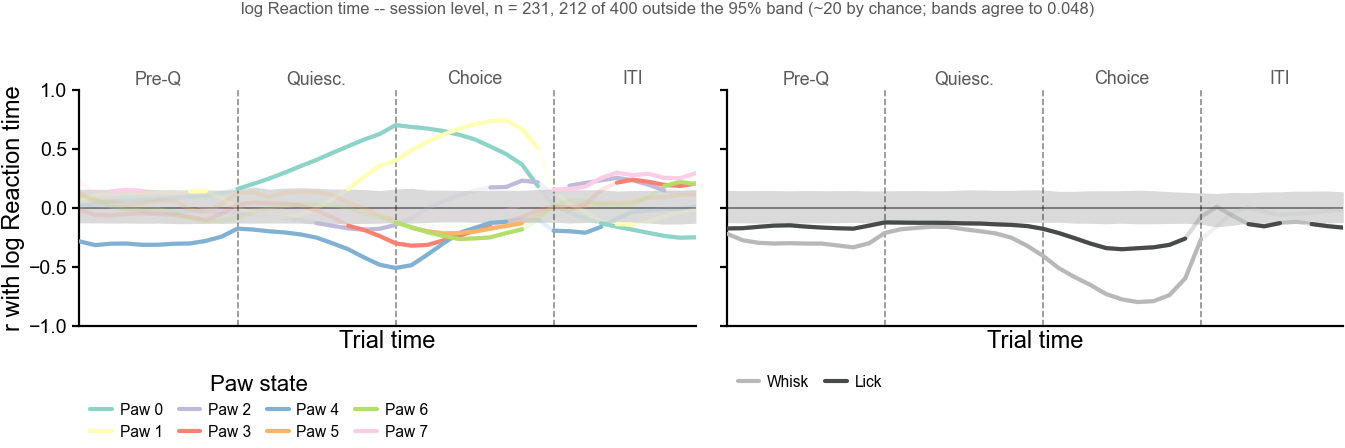

In [48]:
def plot_profile(metric, unit=None, save=True):
    """The lda_shrinkage structural-coefficient panel, with `metric` in place of an LD."""
    prof = correlation_profile(M[metric], unit=unit)
    if prof['r'] is None:
        print(f'{metric}: {prof["note"]} -- no {prof["unit"]} profile to draw')
        return prof

    r, lo, hi = prof['r'], prof['lo'], prof['hi']
    t = np.arange(N_TIMESTEPS)
    fig, axs = plt.subplots(1, 2, figsize=(ps.FIG['double'][0], ps.FIG['single'][1]),
                            sharey=True)

    def panel(ax, ks):
        # ONE grey band, not one per syllable. The null for a correlation depends on the
        # sample size and the shape of the two distributions, not on which syllable it
        # is, so the eight paw bands sit almost on top of each other; drawn in their
        # own colours at any visible alpha they stack into an opaque brown block that
        # hides the traces. The band shown is the WIDEST of the panel's syllables, and
        # the figure title prints how far apart they actually are -- they are close but
        # not identical, so a solid trace can sit just inside the drawn band when its
        # own null is the narrower one. SIGNIFICANCE IS ALWAYS JUDGED PER SYLLABLE
        # against its own band; the drawn band is a guide, not the test.
        band_lo, band_hi = lo[:, ks].min(axis=1), hi[:, ks].max(axis=1)
        ax.fill_between(t, band_lo, band_hi, color=ps.NEUTRAL, alpha=0.28, lw=0, zorder=1)
        for k in ks:
            c = ps.SYLLABLE[SYLLABLES[k]]
            ax.plot(t, r[:, k], color=c, lw=3, alpha=ALPHA_IN_BAND, zorder=2)
            # the SAME trace at full strength, blanked wherever it is inside ITS OWN
            # band, so significance is carried by the ink rather than by a legend
            outside = np.where((r[:, k] >= lo[:, k]) & (r[:, k] <= hi[:, k]),
                               np.nan, r[:, k])
            ax.plot(t, outside, color=c, lw=3, alpha=1.0, label=SYLLABLES[k], zorder=3)
        return float(np.max(hi[:, ks].max(axis=1) - hi[:, ks].min(axis=1)))

    spread = max(panel(axs[0], list(range(N_PAW_STATES))),
                 panel(axs[1], [N_PAW_STATES, N_PAW_STATES + 1]))

    for ax in axs:
        ps.epoch_lines(ax, N_TIMESTEPS, label=True, names=ps.EPOCH_SHORT)
        ps.zero_line(ax)
        ax.set_xlim(0, N_TIMESTEPS - 1)
        ax.set_ylim(-1, 1)
        ax.set_xticks([])
        ax.set_xlabel('Trial time')
    axs[0].set_ylabel(f'r with {LABEL.get(metric, metric)}')
    axs[0].legend(title='Paw state', bbox_to_anchor=(0, -0.16), loc='upper left',
                  ncol=4, frameon=False, fontsize=plt.rcParams['font.size'] * 0.7)
    axs[1].legend(title='', bbox_to_anchor=(0, -0.16), loc='upper left', ncol=2,
                  frameon=False, fontsize=plt.rcParams['font.size'] * 0.7)

    n_out = int(((r < lo) | (r > hi)).sum())
    fig.tight_layout(rect=(0, 0, 1, 0.90))
    fig.suptitle(f'{LABEL.get(metric, metric)} -- {prof["unit"]} level, n = {prof["n"]}, '
                 f'{n_out} of {r.size} outside the 95% band '
                 f'(~{0.05 * r.size:.0f} by chance; bands agree to {spread:.3f})',
                 fontsize=plt.rcParams['font.size'] * 0.75, color='0.35', y=0.985)
    if save:
        ps.savefig(fig, f'nonemerging_syllable_profile_{metric}_{prof["unit"]}', svg=True,
                   bbox_inches='tight')
    plt.show()
    return prof


METRIC_TO_PLOT = 'log_reaction'
_ = plot_profile(METRIC_TO_PLOT)

--- correct ---
wrote figures/nonemerging_syllable_profile_correct_session_poster_23-09-2026.png, figures/nonemerging_syllable_profile_correct_session_poster_23-09-2026.svg


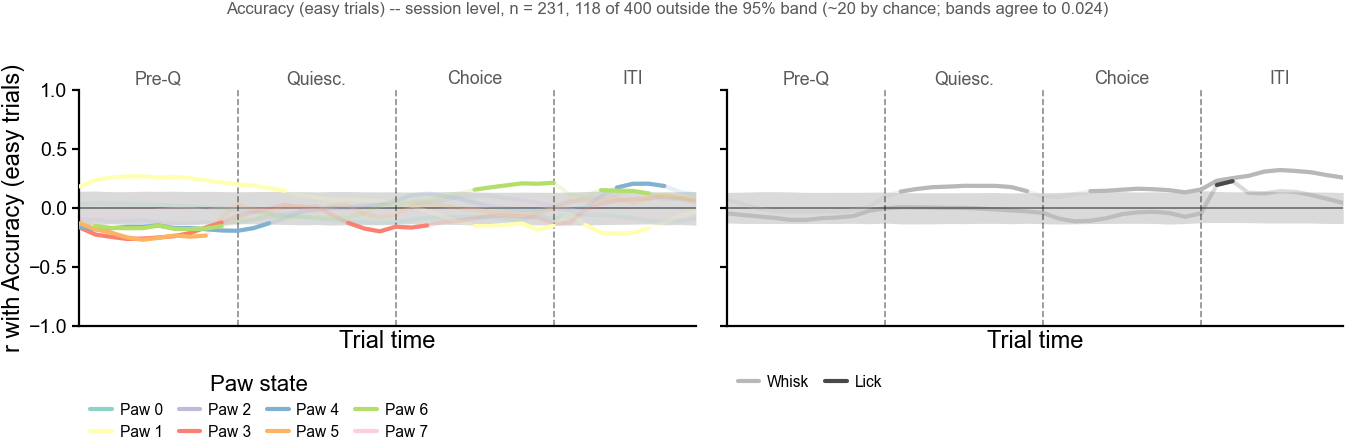

--- log_reaction ---
wrote figures/nonemerging_syllable_profile_log_reaction_session_poster_23-09-2026.png, figures/nonemerging_syllable_profile_log_reaction_session_poster_23-09-2026.svg


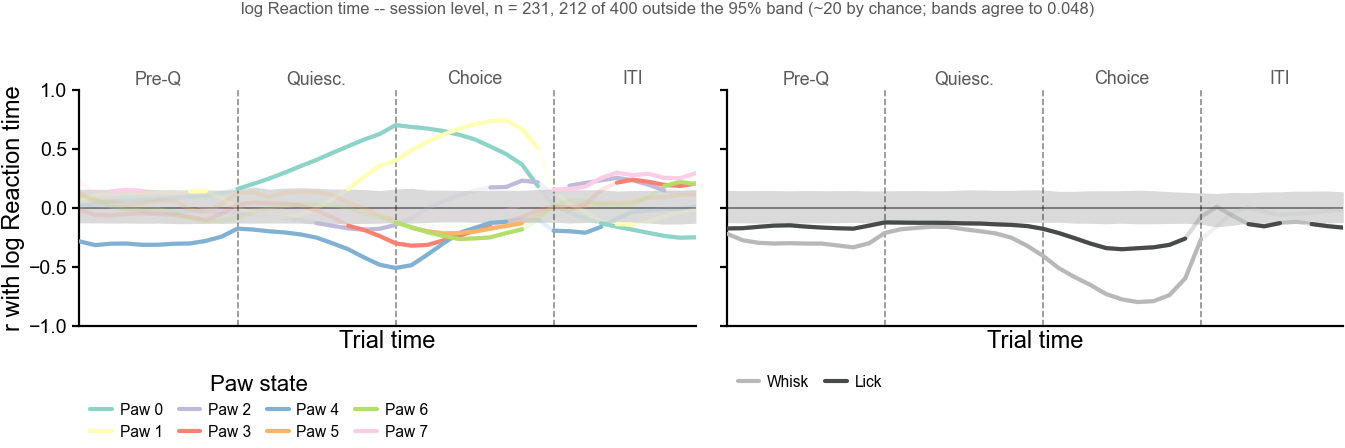

--- log_elongation ---
wrote figures/nonemerging_syllable_profile_log_elongation_session_poster_23-09-2026.png, figures/nonemerging_syllable_profile_log_elongation_session_poster_23-09-2026.svg


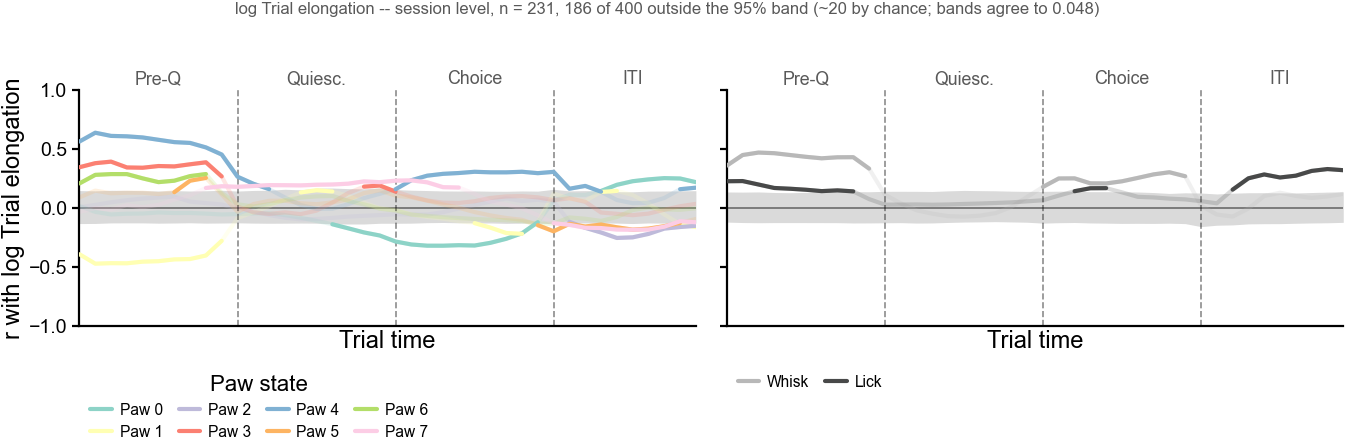

--- bias ---
wrote figures/nonemerging_syllable_profile_bias_session_poster_23-09-2026.png, figures/nonemerging_syllable_profile_bias_session_poster_23-09-2026.svg


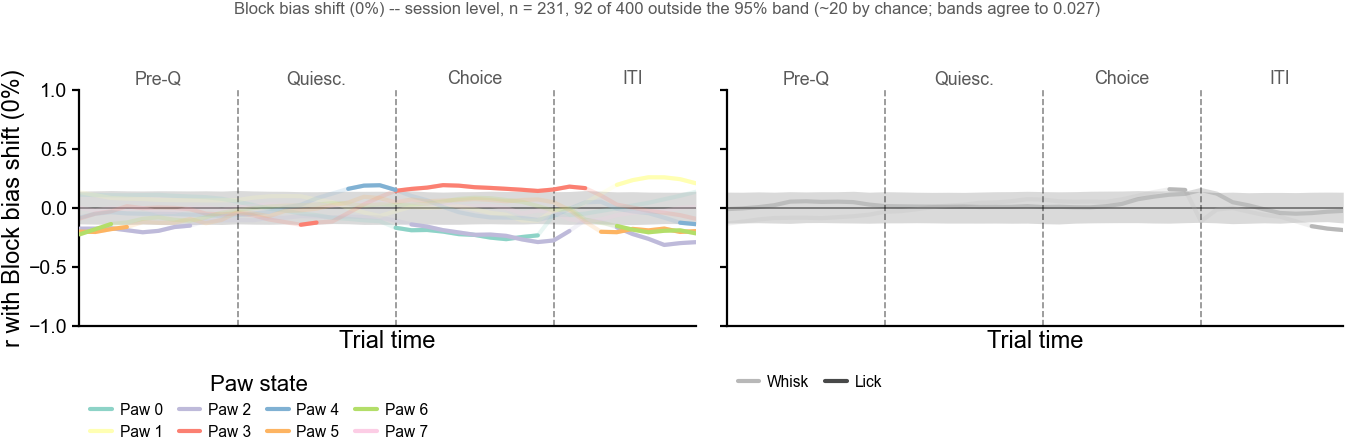

--- signed_choice_bias ---
wrote figures/nonemerging_syllable_profile_signed_choice_bias_session_poster_23-09-2026.png, figures/nonemerging_syllable_profile_signed_choice_bias_session_poster_23-09-2026.svg


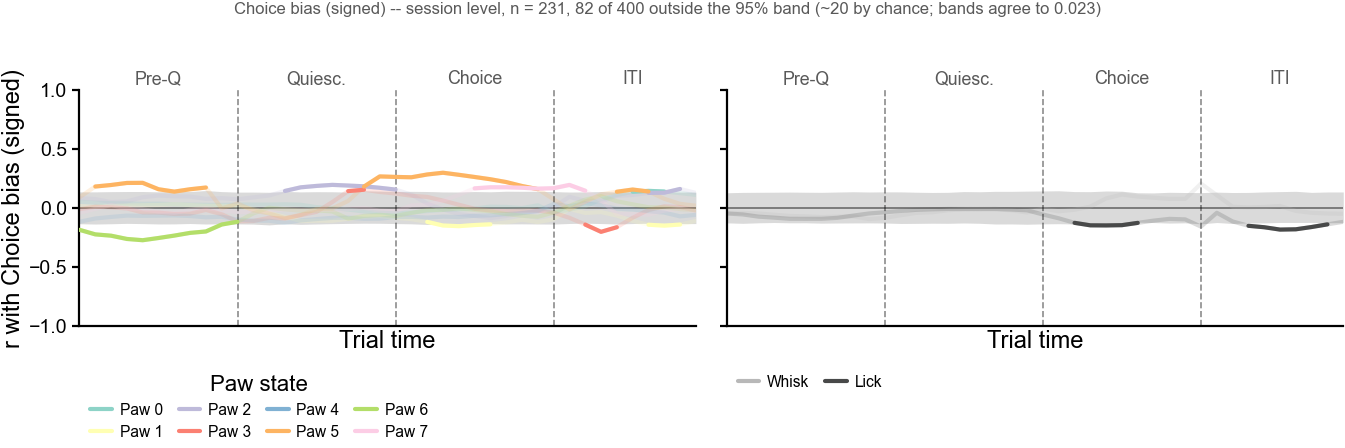

--- choice_bias ---
wrote figures/nonemerging_syllable_profile_choice_bias_session_poster_23-09-2026.png, figures/nonemerging_syllable_profile_choice_bias_session_poster_23-09-2026.svg


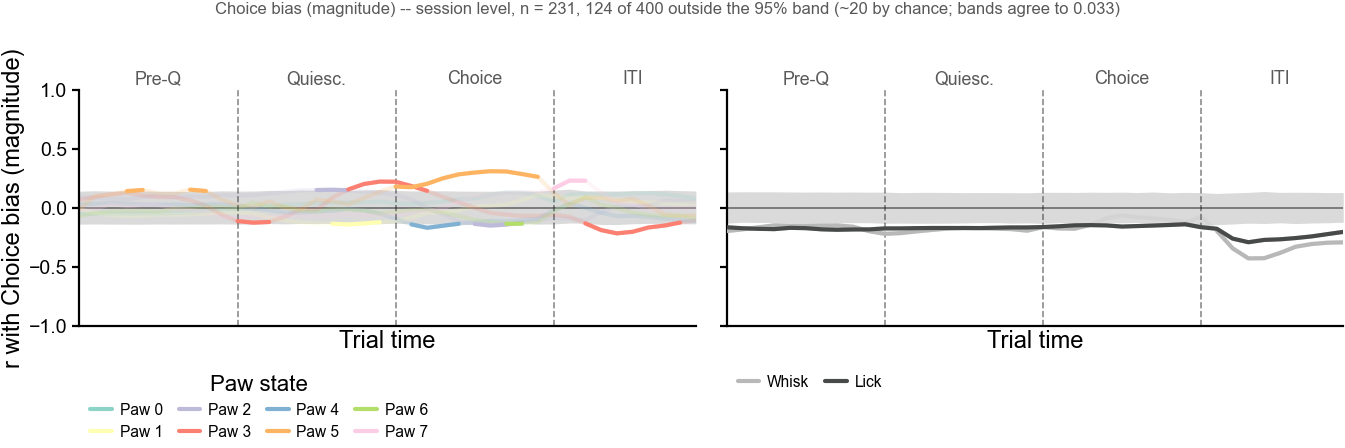

--- p_engaged ---
wrote figures/nonemerging_syllable_profile_p_engaged_session_poster_23-09-2026.png, figures/nonemerging_syllable_profile_p_engaged_session_poster_23-09-2026.svg


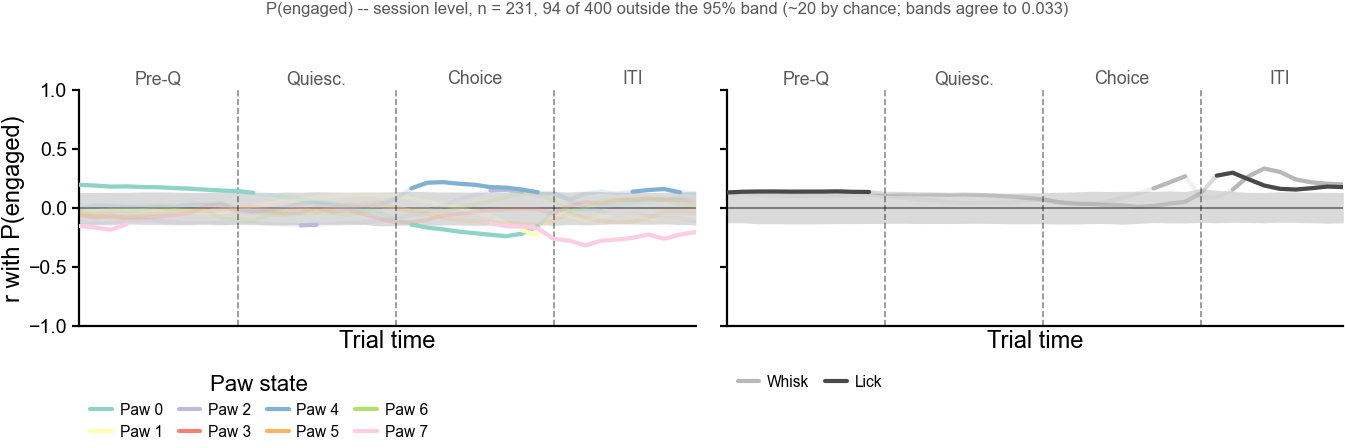

--- p_switch ---
wrote figures/nonemerging_syllable_profile_p_switch_session_poster_23-09-2026.png, figures/nonemerging_syllable_profile_p_switch_session_poster_23-09-2026.svg


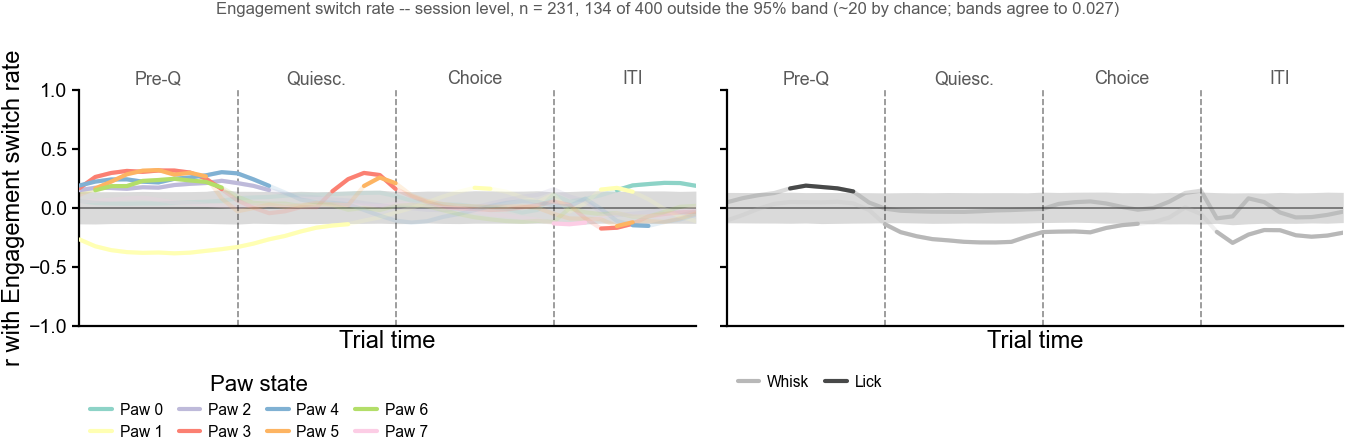

--- p_eng_to_dis ---
wrote figures/nonemerging_syllable_profile_p_eng_to_dis_session_poster_23-09-2026.png, figures/nonemerging_syllable_profile_p_eng_to_dis_session_poster_23-09-2026.svg


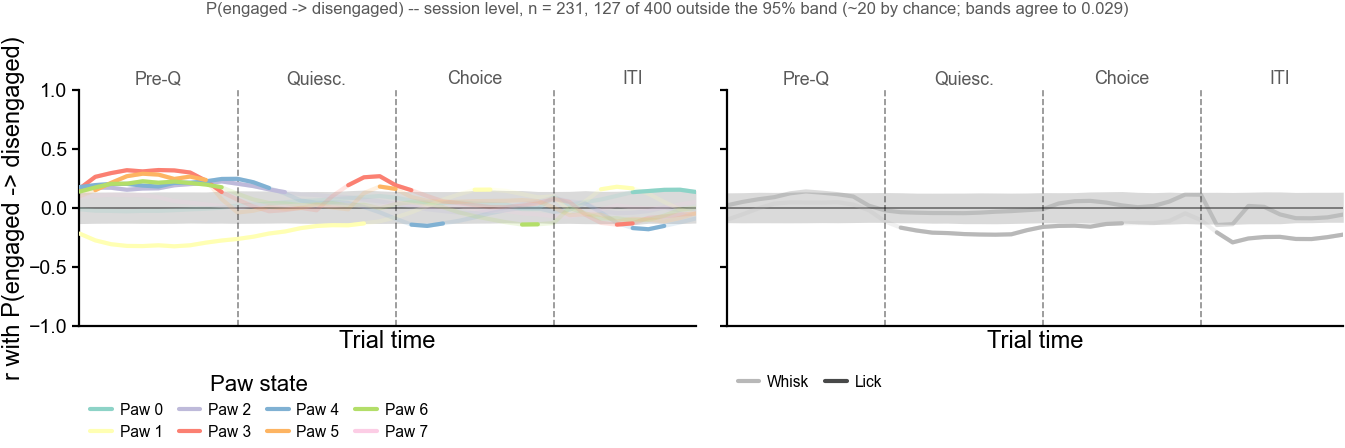

--- p_dis_to_eng ---
wrote figures/nonemerging_syllable_profile_p_dis_to_eng_session_poster_23-09-2026.png, figures/nonemerging_syllable_profile_p_dis_to_eng_session_poster_23-09-2026.svg


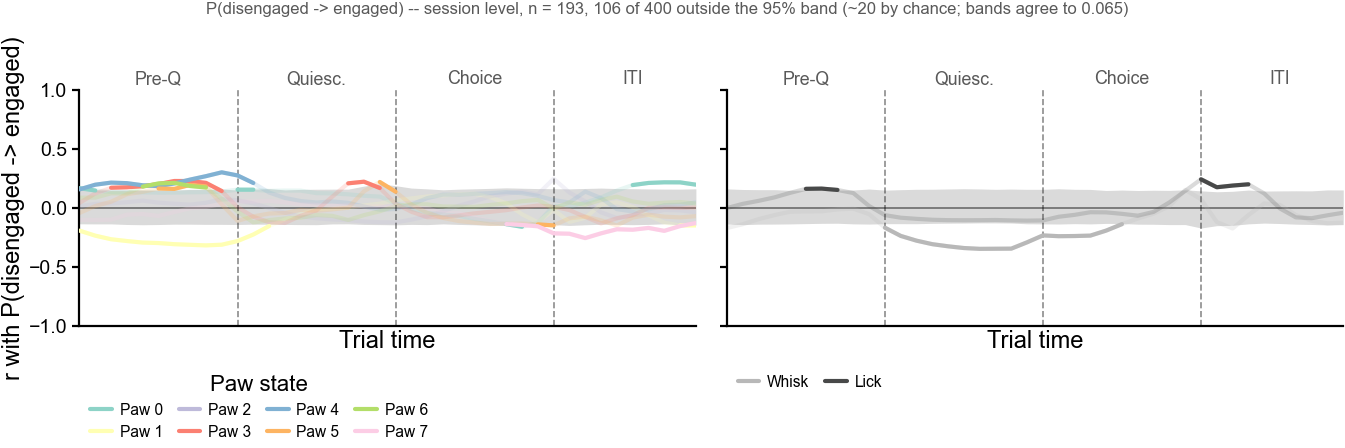

--- trial_count ---
wrote figures/nonemerging_syllable_profile_trial_count_session_poster_23-09-2026.png, figures/nonemerging_syllable_profile_trial_count_session_poster_23-09-2026.svg


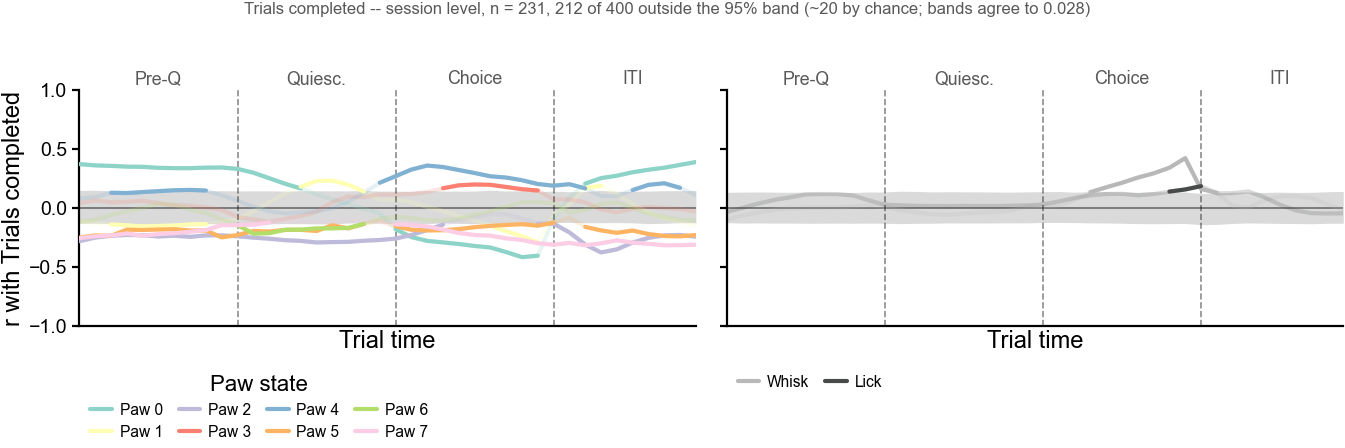

--- log_training ---
wrote figures/nonemerging_syllable_profile_log_training_session_poster_23-09-2026.png, figures/nonemerging_syllable_profile_log_training_session_poster_23-09-2026.svg


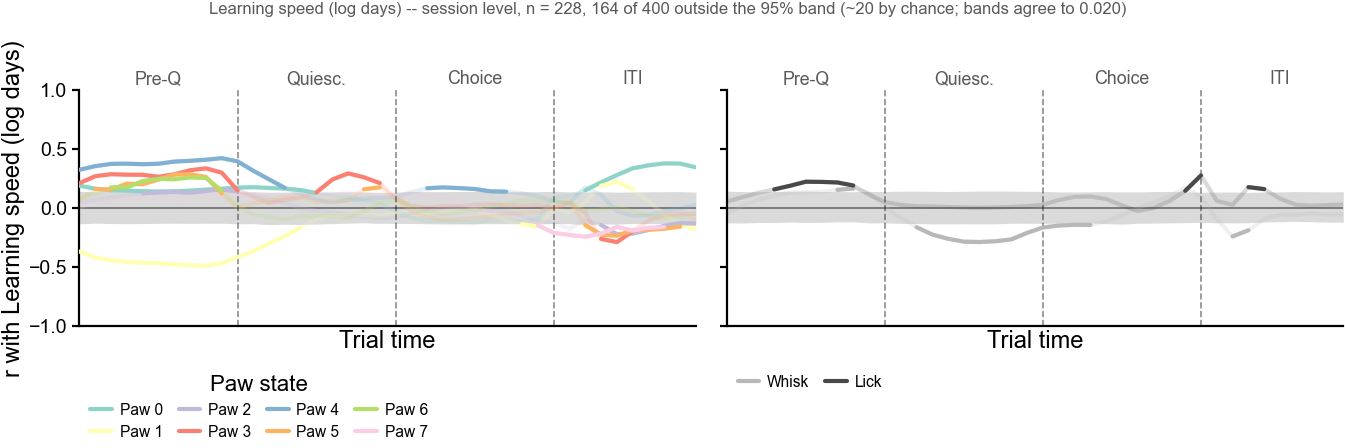

--- LD1 ---
wrote figures/nonemerging_syllable_profile_LD1_session_poster_23-09-2026.png, figures/nonemerging_syllable_profile_LD1_session_poster_23-09-2026.svg


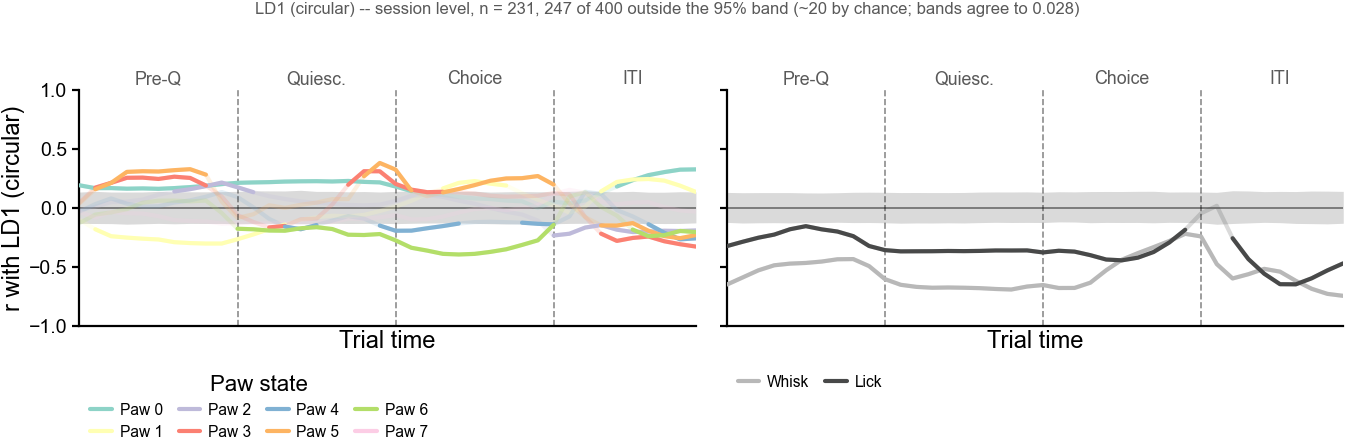

--- LD2 ---
wrote figures/nonemerging_syllable_profile_LD2_session_poster_23-09-2026.png, figures/nonemerging_syllable_profile_LD2_session_poster_23-09-2026.svg


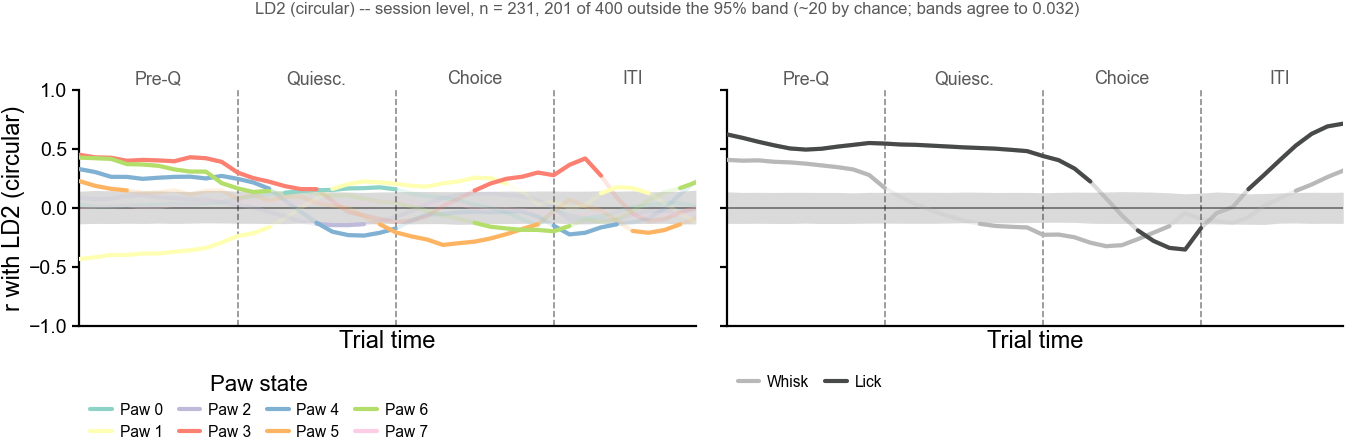

--- LD3 ---
wrote figures/nonemerging_syllable_profile_LD3_session_poster_23-09-2026.png, figures/nonemerging_syllable_profile_LD3_session_poster_23-09-2026.svg


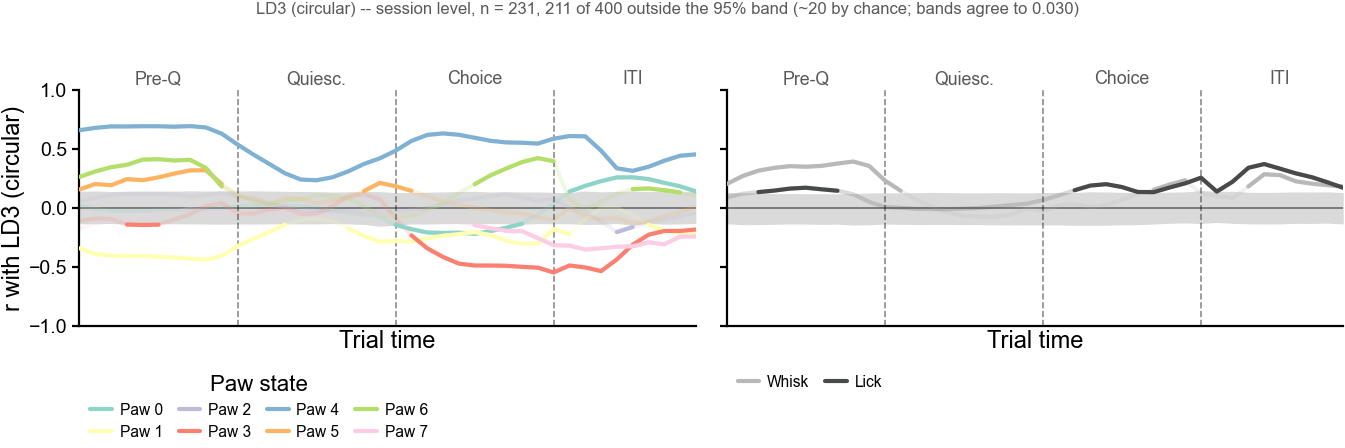

In [49]:
# Every measure, at PROFILE_UNIT. Each figure is written to figures/ as
# nonemerging_syllable_profile_<measure>_<unit>.
PROFILES = {}
for _m in ALL_METRICS:
    print(f'--- {_m} ---')
    PROFILES[_m] = plot_profile(_m)

### All three units, side by side

`max |r|` alone is a maximum over 400 correlated tests and is biased upwards; the column
that carries the evidence is `n_sig`, the number of (timestep, syllable) cells outside
the 95% permutation band, against the ~20 of 400 expected by chance at that band.

A measure with a large `mouse` column and a small `within` column separates animals
without tracking a mouse's own session-to-session swings — that is a trait-like coupling.
The reverse means the syllables read the state of the session, not the identity of the
animal. Both are findings; they are just not the same one.

In [50]:
rows = []
for _m in ALL_METRICS:
    row = {'measure': _m}
    for _u in ('mouse', 'session', 'within'):
        p = correlation_profile(M[_m], unit=_u, n_perms=N_PERMS_PROFILE, seed=1)
        if p['r'] is None:
            row[f'max_r_{_u}'], row[f'n_sig_{_u}'], row[f'n_{_u}'] = np.nan, np.nan, 0
            continue
        out = (p['r'] < p['lo']) | (p['r'] > p['hi'])
        row[f'max_r_{_u}'] = p['r'].flat[np.nanargmax(np.abs(p['r']))]
        row[f'n_sig_{_u}'] = int(out.sum())
        row[f'n_{_u}'] = p['n']
    rows.append(row)

profile_table = pd.DataFrame(rows).set_index('measure')
print(f'{profile_table.filter(like="n_sig").shape[0]} measures; '
      f'{N_TIMESTEPS * SERIES.shape[2]} cells per profile, '
      f'~{0.05 * N_TIMESTEPS * SERIES.shape[2]:.0f} expected outside the band by chance\n')
display(profile_table.round(3))

15 measures; 400 cells per profile, ~20 expected outside the band by chance



,max_r_mouse,n_sig_mouse,n_mouse,max_r_session,n_sig_session,n_session,max_r_within,n_sig_within,n_within
measure,,,,,,,,,
correct,0.429,58,52,0.319,123,231,0.277,28.0,231
log_reaction,-0.841,107,52,-0.800,214,231,-0.732,186.0,231
log_elongation,0.693,94,52,0.635,180,231,0.529,196.0,231
bias,-0.478,72,52,-0.316,93,231,0.345,94.0,231
signed_choice_bias,-0.345,29,52,0.296,77,231,0.236,15.0,231
choice_bias,-0.427,26,52,-0.430,123,231,-0.443,32.0,231
p_engaged,-0.388,14,52,0.332,99,231,0.306,49.0,231
p_switch,-0.418,53,52,-0.387,139,231,-0.278,36.0,231
p_eng_to_dis,-0.385,60,52,-0.328,134,231,0.274,41.0,231


### One panel per measure — where in the trial, and which syllable

wrote figures/nonemerging_syllable_profile_grid_session_poster_23-09-2026.png, figures/nonemerging_syllable_profile_grid_session_poster_23-09-2026.svg


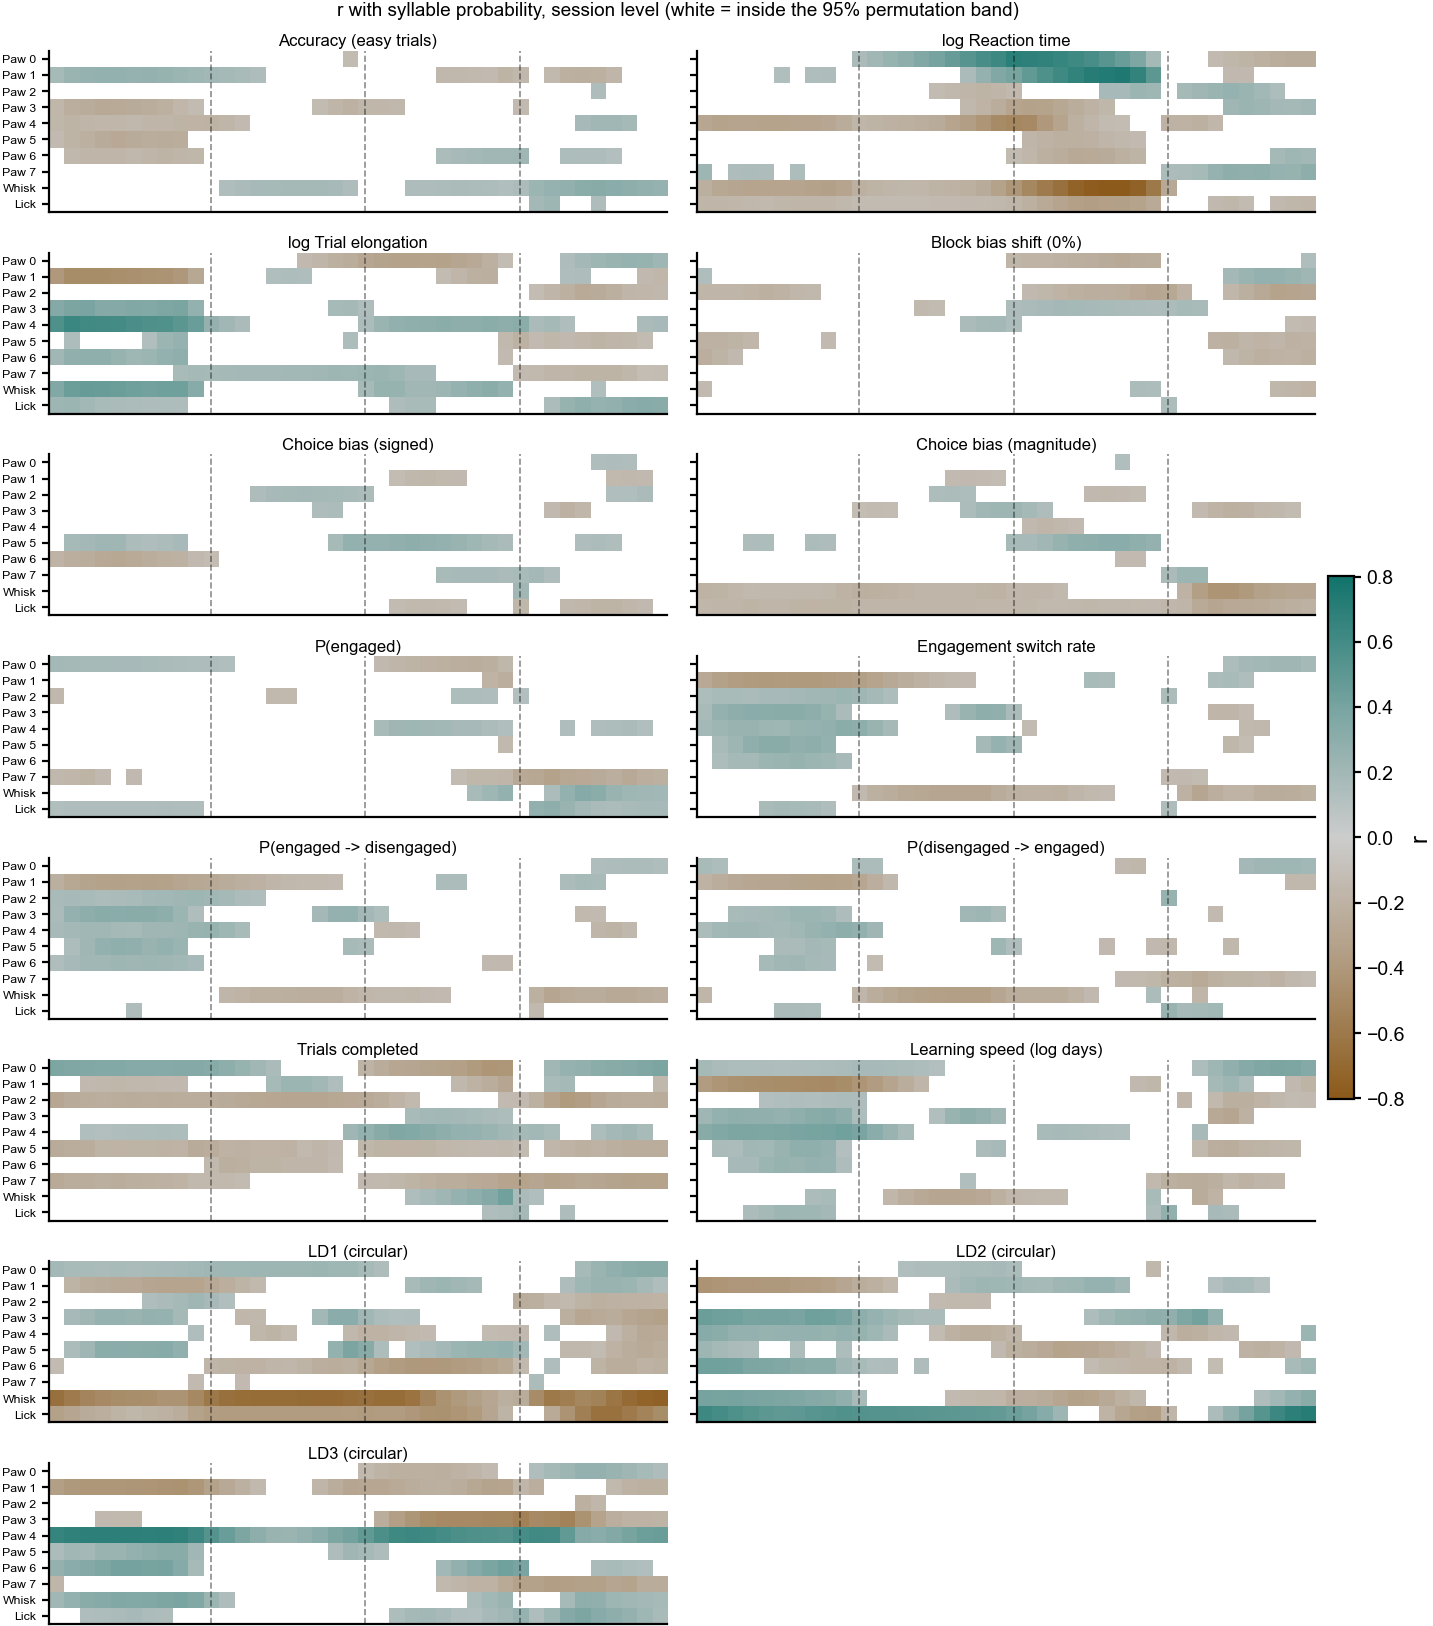

In [51]:
# The same numbers as the traces, as a heatmap, so ten measures fit on one page.
# Rows are syllables, columns are trial time; cells INSIDE the permutation band are
# blanked to white (CORR_CMAP.set_bad) rather than drawn pale, because a heatmap has no
# equivalent of the double-drawn trace and a pale cell reads as a small effect rather
# than as no effect.
shown = [m for m in ALL_METRICS if PROFILES.get(m, {}).get('r') is not None]
ncols = 2
nrows = int(np.ceil(len(shown) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ps.FIG['double'][0],
                                                1.95 * nrows + 1.2),
                         squeeze=False, sharex=True, sharey=True)
vmax = max(np.nanmax(np.abs(PROFILES[m]['r'])) for m in shown)

for i, m in enumerate(shown):
    ax = axes[i // ncols, i % ncols]
    p = PROFILES[m]
    masked = np.where((p['r'] >= p['lo']) & (p['r'] <= p['hi']), np.nan, p['r'])
    im = ax.imshow(masked.T, aspect='auto', cmap=ps.CORR_CMAP, norm=ps.corr_norm(vmax),
                   interpolation='nearest')
    ps.epoch_lines(ax, N_TIMESTEPS)
    ax.set_title(LABEL.get(m, m), fontsize=plt.rcParams['font.size'] * 0.75)
    ax.set_yticks(range(len(SYLLABLES)))
    ax.set_yticklabels(SYLLABLES, fontsize=plt.rcParams['font.size'] * 0.55)
    ax.set_xticks([])
for j in range(len(shown), nrows * ncols):
    axes[j // ncols, j % ncols].set_visible(False)

fig.suptitle(f'r with syllable probability, {PROFILE_UNIT} level '
             '(white = inside the 95% permutation band)',
             fontsize=plt.rcParams['font.size'] * 0.85)
fig.tight_layout()
fig.colorbar(im, ax=axes.ravel().tolist(), label='r', fraction=0.02, pad=0.01)
ps.savefig(fig, f'nonemerging_syllable_profile_grid_{PROFILE_UNIT}', svg=True)
plt.show()

# Part 2 — how individual is each measure?

The question in the prompt — *how much do mice vary between themselves compared to
across [sessions]* — is a variance ratio, and it has a standard name: **repeatability**,
or the intraclass correlation,

$$R \;=\; \frac{\sigma^2_\text{mouse}}{\sigma^2_\text{mouse} + \sigma^2_\text{session}}$$

read as: the correlation you expect between two sessions of the same mouse. $R = 0$ means
a mouse's value tomorrow tells you nothing about its value today; $R = 1$ means the
measure is a property of the animal and the session adds nothing.

### Three things this notebook does that a plain groupby does not

**The components are unbiased, not naive.** $\eta^2$ — between-group sum of squares over
total — is biased **upwards**, badly so when groups are many relative to observations. 52
mouse means estimated from 231 sessions absorb noise: with no true mouse effect at all
this design returns $\eta^2 \approx 0.2$. The estimator here is the ANOVA / Henderson I
one, $\sigma^2_\text{mouse} = (MS_B - MS_W) / n_0$ with $n_0$ the unbalanced-design
coefficient, which is unbiased by construction and can legitimately come out negative
when the true component is near zero. Negatives are reported raw and clipped only where a
ratio needs it.

**Lab is split out, because it is nested inside mouse.** Every mouse is recorded in one
lab, so a measure on which whole labs differ will read as individuality: the between-mouse
variance contains the between-lab variance. `lab/variance_partition.py` gives the three-way
nested decomposition — lab / mouse-within-lab / session-within-mouse — so `share_lab` says
how much of the apparent individuality is a claim about ~10 cohorts rather than 52 animals.
`R_withinlab` is the repeatability with that part removed, and it is the number to quote.

**The null is not zero.** With `PERM_WITHIN_LAB = True` the permutation reassigns sessions
to *labmates*, keeping every lab difference intact, so the null distribution already
contains whatever structure the lab alone produces and the p-value asks for mouse identity
**beyond** lab. The null median is printed with every R for exactly this reason: read R
against it, never against 0.

The bootstrap resamples **mice within lab**, which is the unit that limits precision —
resampling sessions would give an interval several times too narrow.

In [52]:
def icc_oneway(values, groups):
    """Unbiased one-way ANOVA repeatability: (R, sigma2_group, sigma2_within).

    sigma2_group = (MS_between - MS_within) / n0 with the unbalanced-design coefficient
    n0 = (N - sum(n_i^2)/N) / (M - 1). It is NEGATIVE when the true component is near
    zero -- returned as it is, and clipped only inside the ratio.
    """
    v = np.asarray(values, float)
    ok = np.isfinite(v)
    v = v[ok]
    g = pd.factorize(np.asarray(groups)[ok])[0]
    M_, N_ = g.max() + 1, len(v)
    if M_ < 2 or N_ <= M_:
        return np.nan, np.nan, np.nan
    n = np.bincount(g).astype(float)
    mu = np.bincount(g, weights=v) / n
    ms_within = ((v - mu[g]) ** 2).sum() / (N_ - M_)
    ms_between = (n * (mu - v.mean()) ** 2).sum() / (M_ - 1)
    n0 = (N_ - (n ** 2).sum() / N_) / (M_ - 1)
    s2_g = (ms_between - ms_within) / n0
    total = max(s2_g, 0.0) + ms_within
    return (max(s2_g, 0.0) / total if total > 0 else np.nan), s2_g, ms_within


def repeatability(metric, n_perms=N_PERMS_ICC, n_boot=N_BOOT_ICC, seed=0):
    """R with a permutation null and a hierarchical bootstrap, plus the 3-way split."""
    v = M[metric].to_numpy(float)
    ok = np.isfinite(v)
    v, g, l = v[ok], mouse.to_numpy()[ok], lab.to_numpy()[ok]
    out = dict(measure=metric, n_sessions=int(ok.sum()), n_mice=len(np.unique(g)))

    R, s2g, s2w = icc_oneway(v, g)
    out.update(R=R, sigma2_mouse_raw=s2g, sigma2_session=s2w)

    # The same thing in the measure's own units, because a ratio of variances hides how
    # extreme it is: sd_ratio is the typical within-mouse sd over the sd of the mouse
    # means. Around 1 the two are comparable; below ~0.2 a mouse's sessions are so alike
    # that the measure is behaving like a constant of the animal, which is worth checking
    # against how it was produced before it is read as biology.
    by_mouse = pd.Series(v).groupby(g)
    out['sd_within'] = float(by_mouse.std(ddof=0).mean())
    out['sd_between'] = float(by_mouse.mean().std())
    out['sd_ratio'] = (out['sd_within'] / out['sd_between']
                       if out['sd_between'] > 0 else np.nan)

    # --- three-way nested split: lab / mouse(lab) / session(mouse) -------------------
    try:
        vc, design = vp.nested_variance_components(v[:, None], l, g)
        s_lab, s_mouse, s_sess = vc.iloc[0]
        pos = np.clip([s_lab, s_mouse, s_sess], 0, None)
        tot = pos.sum()
        out.update(sigma2_lab_raw=s_lab,
                   share_lab=pos[0] / tot, share_mouse=pos[1] / tot,
                   share_session=pos[2] / tot,
                   R_withinlab=pos[1] / (pos[1] + pos[2]) if pos[1] + pos[2] > 0 else np.nan)
    except (ValueError, AssertionError) as e:
        out.update(sigma2_lab_raw=np.nan, share_lab=np.nan, share_mouse=np.nan,
                   share_session=np.nan, R_withinlab=np.nan, note=type(e).__name__)

    # --- permutation null -----------------------------------------------------------
    # Sessions are reassigned to mice; with PERM_WITHIN_LAB the reassignment stays inside
    # the lab, so every lab difference survives and the p-value is for mouse identity
    # beyond lab. Session counts per mouse are preserved either way, which matters
    # because R's small-sample behaviour depends on them.
    rng = np.random.default_rng(seed)
    null = np.empty(n_perms)
    blocks = [np.where(l == L)[0] for L in np.unique(l)] if PERM_WITHIN_LAB \
        else [np.arange(len(v))]
    for p in range(n_perms):
        perm = g.copy()
        for idx in blocks:
            perm[idx] = rng.permutation(g[idx])
        null[p] = icc_oneway(v, perm)[0]
    out.update(null_median=float(np.nanmedian(null)),
               null_p95=float(np.nanpercentile(null, 95)),
               p_perm=float((null >= R).mean()) if np.isfinite(R) else np.nan)

    # --- hierarchical bootstrap: resample MICE within lab ----------------------------
    lab_of_mouse = pd.Series(l, index=g).groupby(level=0).first()
    boot = np.empty(n_boot)
    for b in range(n_boot):
        vals, keys = [], []
        for L in np.unique(l):
            mice_L = lab_of_mouse[lab_of_mouse == L].index.to_numpy()
            for rep, mo in enumerate(rng.choice(mice_L, len(mice_L), replace=True)):
                w = np.where(g == mo)[0]
                vals.append(v[w])
                # a mouse drawn twice becomes two distinct mice, otherwise the duplicate
                # rows would masquerade as one perfectly reproducible animal
                keys.append(np.full(len(w), f'{mo}#{rep}'))
        boot[b] = icc_oneway(np.concatenate(vals), np.concatenate(keys))[0]
    out.update(ci_lo=float(np.nanpercentile(boot, 2.5)),
               ci_hi=float(np.nanpercentile(boot, 97.5)))
    return out

In [53]:
# log_training is EXCLUDED here, not merely uninteresting: it is one value per mouse, so
# sigma2_session is exactly 0 and R is 1.0 arithmetically. The assert makes the exclusion
# a check rather than a convention -- if a future trial file gives training time per
# session, this fires and the measure moves to SESSION_METRICS on purpose.
for _t in TRAIT_METRICS:
    _w = M.groupby('mouse_name')[_t].std(ddof=0)
    assert np.nanmax(_w) < 1e-12, (
        f'{_t} is declared a per-mouse trait but varies within a mouse '
        f'(max within-mouse sd {np.nanmax(_w):.3g}) -- move it to METRIC_SPEC as '
        "'session'")
print(f'trait measures held out of the repeatability table: {TRAIT_METRICS}')

icc_table = pd.DataFrame([repeatability(m) for m in SESSION_METRICS + ld_cols]) \
              .set_index('measure')
icc_table['label'] = [LABEL.get(m, m) for m in icc_table.index]

_cols = ['n_sessions', 'n_mice', 'R', 'ci_lo', 'ci_hi', 'null_median', 'p_perm',
         'R_withinlab', 'share_lab', 'share_mouse', 'share_session', 'sd_ratio']
print(f'\nrepeatability, {N_SESS} sessions / {N_MICE} mice / {N_LABS} labs; '
      f'permutation {"within lab" if PERM_WITHIN_LAB else "across the cohort"}, '
      f'{N_PERMS_ICC} draws; bootstrap over mice within lab, {N_BOOT_ICC} draws\n')
display(icc_table[_cols].sort_values('R', ascending=False).round(3))

trait measures held out of the repeatability table: ['log_training']

repeatability, 231 sessions / 52 mice / 10 labs; permutation within lab, 1000 draws; bootstrap over mice within lab, 1000 draws



,n_sessions,n_mice,R,ci_lo,ci_hi,null_median,p_perm,R_withinlab,share_lab,share_mouse,share_session,sd_ratio
measure,,,,,,,,,,,,
p_dis_to_eng,193,51,0.952,0.899,0.971,0.230,0.000,0.948,0.073,0.879,0.048,0.134
LD1,231,52,0.935,0.889,0.958,0.385,0.000,0.908,0.319,0.618,0.063,0.190
LD2,231,52,0.923,0.880,0.946,0.565,0.000,0.845,0.527,0.400,0.073,0.241
LD3,231,52,0.901,0.827,0.936,0.196,0.000,0.895,0.071,0.831,0.098,0.236
signed_choice_bias,231,52,0.619,0.460,0.718,0.076,0.000,0.621,0.000,0.621,0.379,0.582
p_switch,231,52,0.608,0.470,0.714,0.075,0.000,0.615,0.000,0.615,0.385,0.518
log_elongation,231,52,0.566,0.389,0.699,0.132,0.000,0.549,0.042,0.527,0.432,0.452
trial_count,231,52,0.473,0.259,0.601,0.288,0.000,0.294,0.275,0.213,0.512,0.672
p_eng_to_dis,231,52,0.428,0.291,0.537,0.064,0.000,0.423,0.009,0.419,0.572,0.715


### Read the top of that table before the figure

`p_dis_to_eng` comes out at the top, above `LD1` — and that is a warning, not a result.
Its `sd_ratio` says a mouse's sessions differ from each other by a small fraction of how
much mice differ from each other, which for a rate estimated from a few dozen trials per
session is not what noise looks like. The likely explanation is in the header: the
GLM-HMM has a **sticky transition matrix fitted per mouse**, so the rate at which a
session appears to recover from disengagement is substantially that mouse's own fitted
parameter read back out. The measure spans 0 to 1 across animals and barely moves within
one.

`p_switch` and `p_eng_to_dis` carry the same caveat with much less force — their
`sd_ratio` is around 0.5–0.7, which is an ordinary measurement — and `p_engaged` is the
mildest of the four, being a posterior mean rather than a rate.

The clean version of this comparison needs one GLM-HMM fit across all mice, with only the
state path free per session. Until then the four hatched bars are a ceiling on what the
engagement measures could show, not an estimate of it.

### The headline figure

wrote figures/nonemerging_repeatability_poster_23-09-2026.png, figures/nonemerging_repeatability_poster_23-09-2026.svg


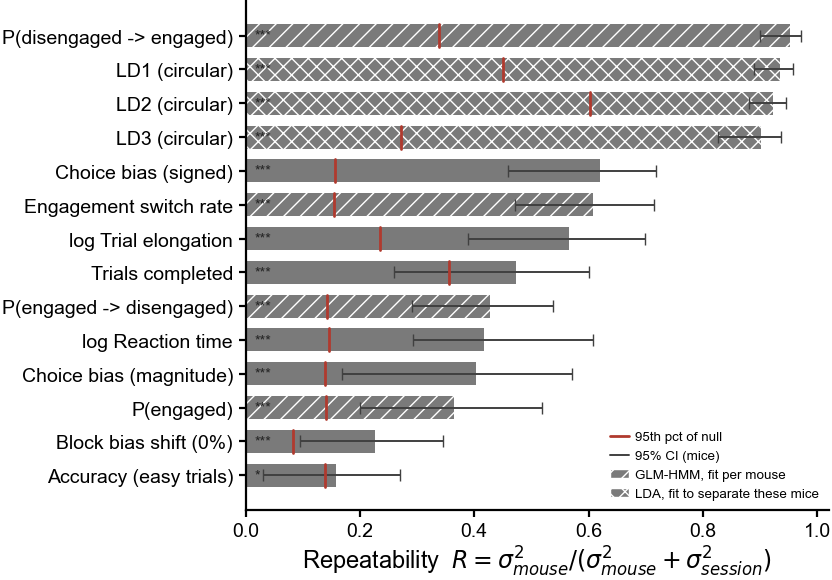

In [54]:
# One bar per measure, sorted. The error bar is the bootstrap CI over mice; the tick is
# the 95th percentile of the permutation null, which is the level a bar has to clear --
# NOT zero, because reassigning sessions to labmates already reproduces some apparent
# individuality.
# LD1-3 are bars here, not a reference line, so the three kinds of measure are read off
# one axis -- but they are NOT a fourth task measure and the texture says so. See the
# header: they were fit to separate these mice on these sessions, so their R is what the
# optimisation achieves in-sample and no held-out claim is being made by this panel.
tab = icc_table.loc[SESSION_METRICS + ld_cols].sort_values('R')
HATCH = {**{m: '//' for m in MODEL_DERIVED}, **{c: 'xx' for c in ld_cols}}
fig, ax = ps.figure('single', scale=1.25)
ypos = np.arange(len(tab))

# HATCHED = read off a model that was fit one mouse at a time (MODEL_DERIVED), so its
# between-mouse variance is part behaviour and part fit and its R is biased upward. Same
# ink, different texture: the distinction is not a third category of measure, it is a
# warning about how one group was produced.
ax.barh(ypos, tab['R'], color=ps.NEUTRAL, height=0.68, zorder=2,
        hatch=[HATCH.get(m, '') for m in tab.index],
        edgecolor='white', linewidth=0,
        xerr=[tab['R'] - tab['ci_lo'], tab['ci_hi'] - tab['R']],
        error_kw=dict(ecolor='0.25', lw=1.4, capsize=4))
for i, (_, row) in enumerate(tab.iterrows()):
    ax.plot([row['null_p95']] * 2, [i - 0.34, i + 0.34], color='#B03A2E', lw=2, zorder=4)
    ax.text(0.015, i, ps.stars(row['p_perm']) if row['p_perm'] < 0.05 else 'n.s.',
            va='center', ha='left', color='0.15', zorder=5,
            fontsize=plt.rcParams['font.size'] * 0.65)

ax.set_yticks(ypos)
ax.set_yticklabels(tab['label'])
ax.set_xlim(0, 1.02)
ax.set_xlabel('Repeatability  $R = \\sigma^2_{mouse} / (\\sigma^2_{mouse} + \\sigma^2_{session})$')
ax.legend(handles=[Line2D([], [], color='#B03A2E', lw=2, label='95th pct of null'),
                   Line2D([], [], color='0.25', lw=1.4, label='95% CI (mice)'),
                   Patch(facecolor=ps.NEUTRAL, hatch='//', edgecolor='white',
                         label='GLM-HMM, fit per mouse'),
                   Patch(facecolor=ps.NEUTRAL, hatch='xx', edgecolor='white',
                         label='LDA, fit to separate these mice')],
          loc='lower right', frameon=False,
          fontsize=plt.rcParams['font.size'] * 0.6)
fig.tight_layout()
ps.savefig(fig, 'nonemerging_repeatability', svg=True)
plt.show()

### How much of that is the lab

Same decomposition, three ways instead of two. A tall `lab` block means the measure
separates cohorts, and its repeatability is a statement about ~10 labs, not 52 mice —
`R_withinlab` in the table above is the same measure with that part taken out.

wrote figures/nonemerging_variance_shares_poster_23-09-2026.png, figures/nonemerging_variance_shares_poster_23-09-2026.svg


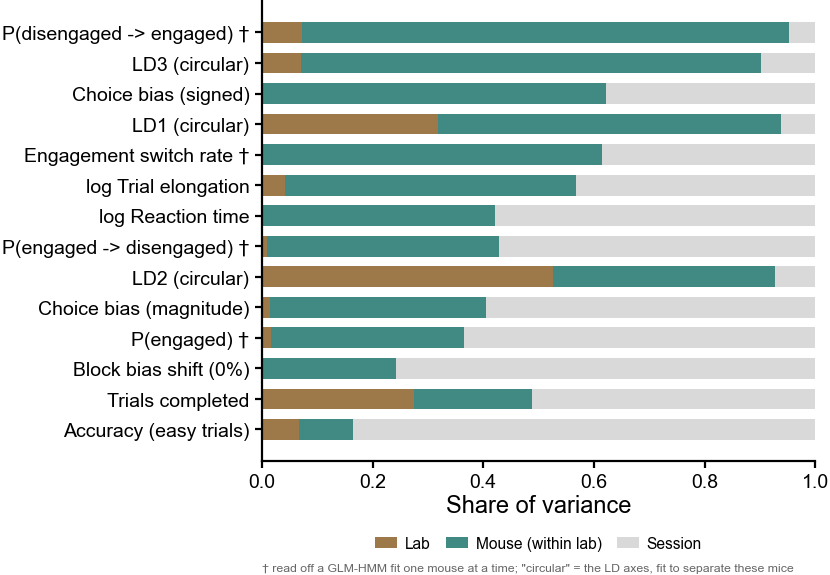

In [55]:
tab = icc_table.loc[SESSION_METRICS + ld_cols].sort_values('share_mouse')
fig, ax = ps.figure('single', scale=1.25)
ypos = np.arange(len(tab))
left = np.zeros(len(tab))
# lab / mouse / session as one diverging-free triple: the lab block is the warm end of
# the correlation map (which the paper already reads as "one direction"), mouse is the
# cool end, session is the neutral grey -- so no new palette enters the paper.
for key, colour, name in [('share_lab', ps.CORR_CMAP(0.12), 'Lab'),
                          ('share_mouse', ps.CORR_CMAP(0.88), 'Mouse (within lab)'),
                          ('share_session', '#D9D9D9', 'Session')]:
    ax.barh(ypos, tab[key], left=left, height=0.68, color=colour, label=name)
    left = left + tab[key].to_numpy()

ax.set_yticks(ypos)
ax.set_yticklabels([f'{lab} †' if m in MODEL_DERIVED else lab
                    for m, lab in tab['label'].items()])
ax.set_xlim(0, 1)
ax.set_xlabel('Share of variance')
ax.text(0, -0.24, '† read off a GLM-HMM fit one mouse at a time; "circular" = the LD '
        'axes, fit to separate these mice', transform=ax.transAxes, color='0.4',
        fontsize=plt.rcParams['font.size'] * 0.55)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.14), ncol=3, frameon=False,
          fontsize=plt.rcParams['font.size'] * 0.7)
fig.tight_layout()
ps.savefig(fig, 'nonemerging_variance_shares', svg=True)
plt.show()

### The same thing without a model

Every mouse's sessions, mice sorted by their own mean. This is what a repeatability of
0.6 and a repeatability of 0.15 actually look like: the question is whether the vertical
spread within a column is small next to the drift across columns.

wrote figures/nonemerging_per_mouse_spread_poster_23-09-2026.png, figures/nonemerging_per_mouse_spread_poster_23-09-2026.svg


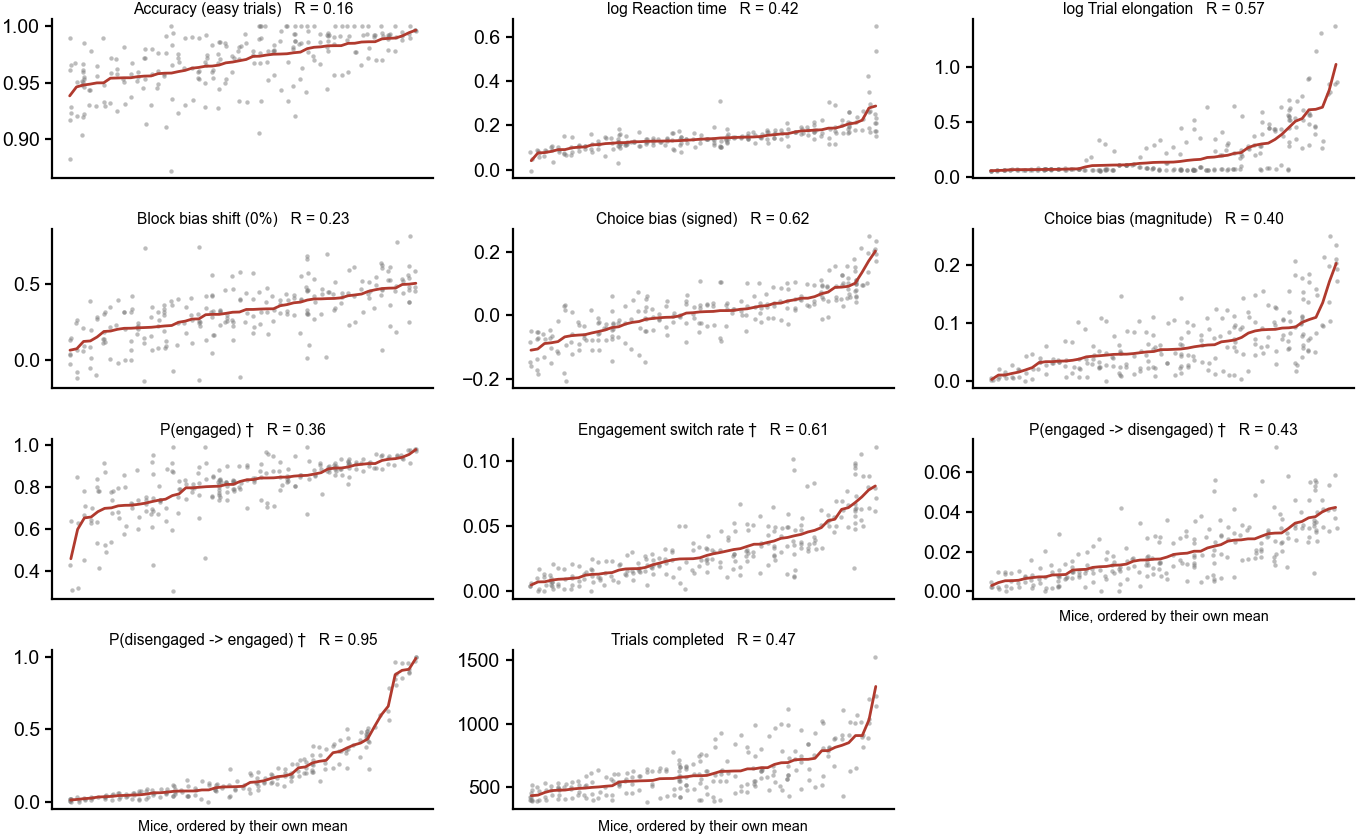

In [56]:
shown = SESSION_METRICS
ncols = 3
nrows = int(np.ceil(len(shown) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ps.FIG['double'][0], 2.2 * nrows),
                         squeeze=False)
for i, m in enumerate(shown):
    ax = axes[i // ncols, i % ncols]
    d = M[[m]].assign(mouse=mouse.to_numpy()).dropna()
    order = d.groupby('mouse')[m].mean().sort_values().index
    rank = {mo: k for k, mo in enumerate(order)}
    xr = d['mouse'].map(rank).to_numpy(float)
    ax.scatter(xr + RNG.uniform(-0.18, 0.18, len(xr)), d[m], s=10, alpha=0.5,
               color=ps.NEUTRAL, linewidths=0, zorder=1)
    mu = d.groupby('mouse')[m].mean().reindex(order)
    ax.plot(np.arange(len(order)), mu.to_numpy(), color='#B03A2E', lw=2, zorder=2)
    r = icc_table.loc[m, 'R']
    ax.set_title(f'{LABEL[m]}{" †" if m in MODEL_DERIVED else ""}   R = {r:.2f}',
                 fontsize=plt.rcParams['font.size'] * 0.7)
    ax.set_xticks([])
    if i >= len(shown) - ncols:          # bottom row only: the axis is the same in all
        ax.set_xlabel('Mice, ordered by their own mean', labelpad=8,
                      fontsize=plt.rcParams['font.size'] * 0.65)
for j in range(len(shown), nrows * ncols):
    axes[j // ncols, j % ncols].set_visible(False)
fig.tight_layout()
ps.savefig(fig, 'nonemerging_per_mouse_spread', svg=True)
plt.show()

# Part 3 — the same test the syllables took

A repeatability is one measure at a time. The syllable result is a *joint* claim: given
one held-out session, name which of 52 mice it came from. Running that protocol on the
vector of task measures puts the two on one axis — same cohort, same leave-one-session-out
loop, same balanced training draw, same classifier — and answers how much of the
identifiability in the syllables a standard behavioural report would already have found.

**`log_training` is excluded from the feature vector.** It is constant within a mouse, so
it is not a measurement of the session at all — it is a near-label, and including it
inflates the score for a reason that has nothing to do with behaviour. The code drops
every trait column by construction rather than by a hand-written list.

**The syllable comparison here is not `lda_shrinkage`'s headline number.** That one picks
its shrinkage by nested CV inside each outer fold; this one uses a fixed value so the two
feature sets are treated identically and the loop stays short. Expect it near, but not
equal to, the published 0.885 — and quote `lda_shrinkage` for the syllable figure, not
this cell.

In [57]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

SYLLABLE_SHRINKAGE = 0.5
# Fixed, not selected. lda_shrinkage chooses this by nested CV inside every outer fold,
# which is the correct protocol and about +0.03 of score; here both feature sets get a
# fixed value so the comparison is like for like and the loop is minutes rather than
# hours. 0.5 is the value that run settled on.
RUN_SYLLABLE_ID = True     # False skips the ~2 min syllable loop and plots metrics alone


def balanced_draw(y_sub, rng, cap=N_PER_MOUSE):
    """Indices taking at most `cap` sessions per mouse. A MAXIMUM, not a minimum: every
    mouse stays a class and sparse ones contribute what they have."""
    idx = []
    for m in np.unique(y_sub):
        w = np.where(y_sub == m)[0]
        idx.extend(rng.choice(w, min(cap, len(w)), replace=False))
    return np.array(idx)


def loso_identification(X, y, shrinkage, n_repeats=ID_REPEATS, seed=0, shuffle=False):
    """Leave-one-session-out mouse identification. Returns one accuracy per repeat."""
    scores = []
    for rep in range(n_repeats):
        rng = np.random.default_rng(seed + rep)
        y_use = rng.permutation(y) if shuffle else y
        hit = np.empty(len(X), dtype=bool)
        for i in range(len(X)):
            rest = np.setdiff1d(np.arange(len(X)), i)
            tr = rest[balanced_draw(y_use[rest], rng)]
            k = len(np.unique(y_use[tr]))
            mdl = LinearDiscriminantAnalysis(solver='eigen', shrinkage=shrinkage,
                                             priors=np.ones(k) / k).fit(X[tr], y_use[tr])
            hit[i] = mdl.predict(X[i:i + 1])[0] == y_use[i]
        scores.append(hit.mean())
    return np.array(scores)


ID_MAX_MISSING = 0.05
# A measure missing from more than this fraction of sessions is dropped from the FEATURE
# VECTOR rather than costing those sessions, because the alternative is worse both ways:
# dropping the rows changes the cohort the syllable comparison is run on, and imputing
# the mean invents a value the mouse never produced, which the classifier then learns as
# that mouse's signature. p_dis_to_eng is the measure this rule is here for -- it is NaN
# wherever a session had too few disengaged trials to estimate a recovery rate.
id_feats = [m for m in SESSION_METRICS
            if M[m].isna().mean() <= ID_MAX_MISSING]
_out = [m for m in SESSION_METRICS if m not in id_feats]
if _out:
    print('dropped from the feature vector for missing values: '
          + ', '.join(f'{m} ({M[m].isna().mean():.0%})' for m in _out))
sub = M[id_feats].dropna()
y_all = pd.factorize(mouse.reindex(sub.index))[0]
# LDA is invariant to any invertible affine map of the features, so this z-score cannot
# move the score -- it is here only so the shrinkage floor means the same thing in every
# column, since a fixed shrinkage mixes with a SCALED IDENTITY.
Xm = ((sub - sub.mean()) / sub.std()).to_numpy(float)
print(f'metric vector: {Xm.shape[0]} sessions x {Xm.shape[1]} measures, '
      f'{len(np.unique(y_all))} mice '
      f'({len(M) - len(sub)} sessions dropped for a missing measure)')

results = {}
results['Task measures'] = loso_identification(Xm, y_all, ID_SHRINKAGE)
results['Task measures\n(shuffled)'] = loso_identification(Xm, y_all, ID_SHRINKAGE,
                                                           shuffle=True)
if RUN_SYLLABLE_ID:
    Xs = X_syl.loc[sub.index].to_numpy(float)
    results['Syllables\n(360 features)'] = loso_identification(Xs, y_all,
                                                               SYLLABLE_SHRINKAGE)
CHANCE = 1 / len(np.unique(y_all))
for k, v in results.items():
    print(f'{k.replace(chr(10), " "):28s} {v.mean():.3f} +/- {v.std():.3f}  '
          f'({v.mean() / CHANCE:.0f}x chance)')
print(f'chance = 1/{len(np.unique(y_all))} = {CHANCE:.3f}')

dropped from the feature vector for missing values: p_dis_to_eng (16%)
metric vector: 231 sessions x 10 measures, 52 mice (0 sessions dropped for a missing measure)
Task measures                0.291 +/- 0.017  (15x chance)
Task measures (shuffled)     0.022 +/- 0.011  (1x chance)
Syllables (360 features)     0.870 +/- 0.013  (45x chance)
chance = 1/52 = 0.019


wrote figures/nonemerging_identification_poster_23-09-2026.png, figures/nonemerging_identification_poster_23-09-2026.svg


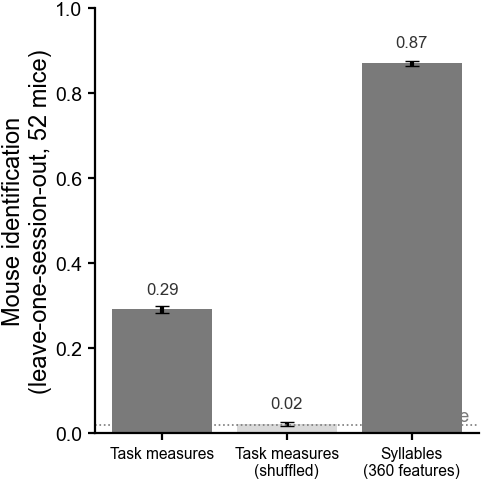

In [58]:
fig, ax = ps.figure('square', scale=0.75)
names = list(results)
vals = [results[k].mean() for k in names]
errs = [results[k].std() / np.sqrt(len(results[k])) for k in names]
colors = [ps.NEUTRAL if 'shuffled' not in k else '#D9D9D9' for k in names]
ax.bar(names, vals, yerr=errs, color=colors, capsize=5)
ax.axhline(CHANCE, color=ps.NEUTRAL, ls=':', lw=1.2)
# right edge, inside the axes: at the left it sits under the first bar and is clipped
ax.text(len(names) - 0.5, CHANCE, 'chance ', ha='right', va='bottom', color=ps.NEUTRAL,
        fontsize=plt.rcParams['font.size'] * 0.8)
for i, v in enumerate(vals):
    ax.text(i, v + 0.03, f'{v:.2f}', ha='center', va='bottom',
            fontsize=plt.rcParams['font.size'] * 0.75, color='0.2')
ax.set_ylim(0, 1)
ax.set_ylabel(f'Mouse identification\n(leave-one-session-out, {len(np.unique(y_all))} mice)')
ax.tick_params(axis='x', labelsize=plt.rcParams['font.size'] * 0.7)
fig.tight_layout()
ps.savefig(fig, 'nonemerging_identification', svg=True)
plt.show()

### Which single measure carries it

The joint score is not a sum of the parts — measures that are individually weak can be
jointly informative if their errors are independent — so this is a description of the
feature set rather than a decomposition of the score above. It is computed on one repeat,
because a one-dimensional LDA is a nearest-class-mean rule and its draw dependence is
negligible next to the difference between measures.

**LD1–LD3 are on the panel too, and they are the reason to look at it.** A single LD axis
is one number per session, exactly like a single task measure, so the two are directly
comparable on both axes — and the axes are the same question asked twice: repeatability is
how far apart the mice sit relative to their own session spread, single-measure
identification is whether that is enough to name the animal. The task measures should
trace out the relation between them; the LD axes say where a dimension built *for* this
job lands on the same plot. They are open markers throughout, because they were fit to
separate these 52 mice on these 231 sessions and neither of their coordinates is an
out-of-sample number. The reported correlation is computed on the **task measures only**,
for the same reason.

,accuracy,R,label,model_derived,circular,x_chance
LD2,0.165,0.923,LD2 (circular),False,True,8.554
log_elongation,0.143,0.566,log Trial elongation,False,False,7.429
LD1,0.134,0.935,LD1 (circular),False,True,6.978
log_reaction,0.108,0.418,log Reaction time,False,False,5.628
LD3,0.108,0.901,LD3 (circular),False,True,5.628
signed_choice_bias,0.048,0.619,Choice bias (signed),False,False,2.476
p_engaged,0.048,0.365,P(engaged),True,False,2.476
trial_count,0.048,0.473,Trials completed,False,False,2.476
correct,0.043,0.159,Accuracy (easy trials),False,False,2.251
choice_bias,0.043,0.404,Choice bias (magnitude),False,False,2.251


wrote figures/nonemerging_R_vs_identification_poster_23-09-2026.png, figures/nonemerging_R_vs_identification_poster_23-09-2026.svg


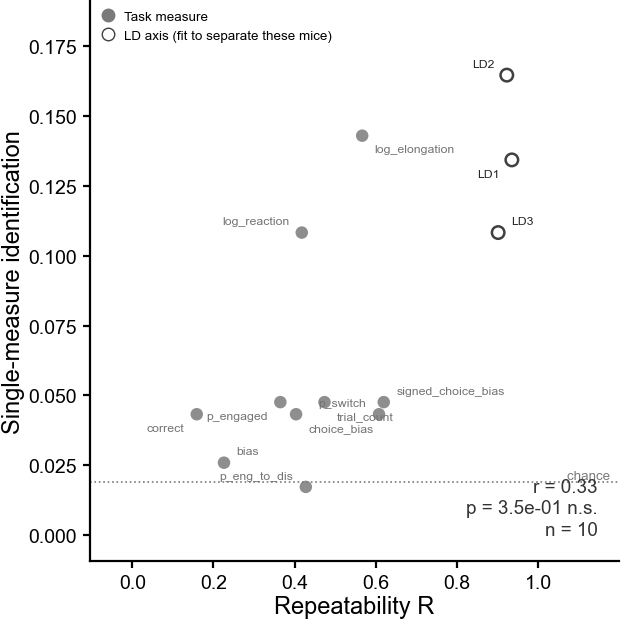

In [59]:
# The LD axes join the task measures one column at a time, on the SAME rows and with the
# same z-scoring, so a point's x and y mean the same thing wherever it sits. They are
# complete over the cohort (checked), so no row is lost and nothing is imputed.
assert not M.loc[sub.index, ld_cols].isna().any().any(), (
    'an LD axis is missing on some cohort session; it cannot share these rows')
single_feats = id_feats + ld_cols
Xsingle = M.loc[sub.index, single_feats]
Xsingle = ((Xsingle - Xsingle.mean()) / Xsingle.std()).to_numpy(float)

per_measure = pd.DataFrame({
    'accuracy': [loso_identification(Xsingle[:, [i]], y_all, ID_SHRINKAGE, n_repeats=1)[0]
                 for i in range(Xsingle.shape[1])],
    'R': [icc_table.loc[m, 'R'] for m in single_feats],
    'label': [LABEL[m] for m in single_feats],
    'model_derived': [m in MODEL_DERIVED for m in single_feats],
    'circular': [m in ld_cols for m in single_feats],
}, index=single_feats).sort_values('accuracy', ascending=False)
per_measure['x_chance'] = per_measure['accuracy'] / CHANCE
display(per_measure.round(3))

# Repeatability should predict single-measure identifiability -- they are two readings of
# the same signal-to-noise ratio -- and a measure that breaks the relation is worth a look
# (usually it is one with a strongly non-normal distribution, which R assumes and the
# classifier does not).
task = per_measure[~per_measure['circular']]
circ = per_measure[per_measure['circular']]

fig, ax = ps.figure('square', scale=0.95)
# The regression and the r are fit on the TASK MEASURES ONLY. Including the LD axes would
# let three points that were optimised for this exact separation set the slope, and the
# line would then be a statement about the optimisation rather than about the measures.
ps.corr_panel(ax, task['R'], task['accuracy'], color=ps.NEUTRAL,
              xlabel='Repeatability R', ylabel='Single-measure identification',
              annotate='lower right')
# open markers, same grey: the LD axes are on the same axes as everything else, and the
# hollow marker is the only thing that says "not an out-of-sample number"
ax.scatter(circ['R'], circ['accuracy'], s=plt.rcParams['lines.markersize'] ** 2,
           facecolors='none', edgecolors='0.25', linewidths=1.8, zorder=4)
ax.axhline(CHANCE, color=ps.NEUTRAL, ls=':', lw=1.2)
ax.text(0.99, CHANCE, 'chance ', transform=ax.get_yaxis_transform(), ha='right',
        va='bottom', color=ps.NEUTRAL, fontsize=plt.rcParams['font.size'] * 0.6)
# The correlation in the corner is there for completeness and is not the reason for the
# panel -- with this few points it can only detect an enormous effect. What the panel is
# for is naming which measure sits where, so label every point.
ax.margins(x=0.34, y=0.18)     # room for the labels inside the axes
# Six of the task measures land within 0.005 of each other just above chance, so a single
# offset direction stacks their labels. Four-phase placement (left/right x above/below)
# separates them without a layout solver, which is not installed here.
OFFSETS = [(-9, 6, 'right'), (9, 6, 'left'), (-9, -12, 'right'), (9, -12, 'left')]
for k, (nm, row) in enumerate(per_measure.sort_values('accuracy').iterrows()):
    dx, dy, ha = OFFSETS[k % 4]
    ax.annotate(nm, (row['R'], row['accuracy']), textcoords='offset points',
                xytext=(dx, dy), ha=ha,
                fontsize=plt.rcParams['font.size'] * 0.55,
                color='0.15' if row['circular'] else '0.45')
ax.legend(handles=[Line2D([], [], ls='', marker='o', color=ps.NEUTRAL,
                          label='Task measure'),
                   Line2D([], [], ls='', marker='o', markerfacecolor='none',
                          markeredgecolor='0.25', color='none',
                          label='LD axis (fit to separate these mice)')],
          loc='upper left', frameon=False,
          fontsize=plt.rcParams['font.size'] * 0.6)
fig.tight_layout()
ps.savefig(fig, 'nonemerging_R_vs_identification', svg=True)
plt.show()

## What gets written out

In [60]:
if SAVE_TABLES:
    stamp = pd.Timestamp.today().strftime('%d-%m-%Y')
    out_icc = HERE / f'nonemerging_repeatability_{stamp}.csv'
    out_prof = HERE / f'nonemerging_syllable_profiles_{stamp}.csv'
    out_sess = HERE / f'nonemerging_session_metrics_{stamp}.csv'
    icc_table.to_csv(out_icc)
    profile_table.to_csv(out_prof)
    # the session table too: every downstream question about these measures should start
    # from the same 231 rows rather than rebuild them and get a different cohort
    M.assign(mouse_name=mouse.to_numpy()).to_csv(out_sess)
    for p in (out_icc, out_prof, out_sess):
        print(f'wrote {p.relative_to(_root)}')

print('\nfigures written to ' + str(ps.FIGDIR.relative_to(_root.parent)))

wrote non_emerging/nonemerging_repeatability_23-09-2026.csv
wrote non_emerging/nonemerging_syllable_profiles_23-09-2026.csv
wrote non_emerging/nonemerging_session_metrics_23-09-2026.csv

figures written to paper-individuality/figures


## Reading it back

**Part 1** says which syllables, and when in the trial, move with each task measure. A
trace that leaves the band at the mouse level and stays inside it within mouse is a
*trait* coupling: the movement pattern separates animals along with the measure, but does
not follow a given animal's good and bad days. The reverse is a *state* coupling. Nothing
here is causal in either direction, and both variables are measured on the same trials of
the same sessions, so a shared nuisance — session length, video quality, time of day —
produces the same picture as a shared mechanism.

**Part 2** says how much of each measure is the animal. Read `R` against `null_median`
and not against zero, read `share_lab` before believing `R`, and treat `R_withinlab` as
the individuality number. A measure whose `R` is high but whose `share_lab` is a third of
the variance is telling you about rigs and cohorts.

**Part 3** puts the two feature sets on one axis. The gap between the task-measure score
and the syllable score is the part of individual identity that a standard behavioural
report does not capture — which is the reason the syllable pipeline exists.

### What this design cannot do

- **Lab and mouse cannot be fully separated.** Every mouse is in one lab; centring,
  splitting or modelling the lab changes which of the two absorbs the shared variance and
  none of it decides which one *caused* it.
- **Sessions are not exchangeable in time.** They are consecutive proficient sessions, so
  `sigma2_session` contains drift as well as noise, and a measure that is trending within
  a mouse looks less repeatable than one that is stationary at the same noise level. A
  session-index covariate would separate those; there is no such term here.
- **3–13 sessions per mouse.** R is estimated from few sessions for most animals, which is
  what the bootstrap interval is for; the point estimate alone is worth less than it looks.
- **The four engagement measures are not raw observables.** The GLM-HMM behind them was
  fit one mouse at a time, so part of what separates mice in them is what separates their
  fits. `p_dis_to_eng` is the clearest case and should not be quoted as an individuality
  result from this notebook; `p_switch` and `p_eng_to_dis` are much less affected but are
  not clean either. One model fit across all mice, with only the state path free per
  session, would settle it.
- **`trial_count` is in the table as a control, not as a finding.** It is a property of
  how long the experimenter ran the session at least as much as of the mouse, and its
  variance shares should be read as a rough floor for how much apparent individuality
  this design manufactures from scheduling alone.